### Variants in 80k MPRA were prioritized using Enformer
- All the standing variation >1% AF (n: 21k neuro; 11k cardiac; 2.5k actionable, 1k random genes) was used within 27.000 disease associated and random regions as well as 35k variants which are more rare (10k for the disease associted and 5k around random genes).
- The latter groups was priroitized using Enformer because the number of variants within these regions of interest was outnumbering the possibility to test all of them => Variant effect was predicted using the difference between alternative and reference of the DNase tracs

- How well did the prioritization of variants work with enformer?
- How well did the prioritization of elements work with enformer?

# TODO: 
- check and understand: /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/playground/thoughtful_way_annotating_MPRAlm.ipynb


In [3]:
import pandas as pd
import numpy as np
import yaml
import os
from collections import defaultdict
from importlib import reload
import math # check for nan
import matplotlib.pyplot as plt # plt.show()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [24]:
col_name = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class' # SNV
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

write_output = False

# helpful functions
import ast

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

# Regular expression pattern to extract variant notation
variant_pattern = r'\b(?:[XY]|\d+)-\d+-[ACGT]-[ACGT]\b'

### How well did the prioritization of variants work with enformer?
1. For the variants in potential CREs around disease associated genes
#### Read the Metadata file of the variants and add the allele frequency information from gnomad => grouping of AF is possible


In [5]:
gnomad_data_all_variants = pd.read_csv(config['files']['creating']['gnomad_data_all_variants_local'], sep="\t") # 46374
# add gnomad prefix to all the columns
gnomad_data_all_variants.columns = ['gnomad_' + col for col in gnomad_data_all_variants.columns]

gnomad_data_all_variants.columns

Index(['gnomad_header', 'gnomad_chrom', 'gnomad_pos', 'gnomad_ref',
       'gnomad_alt', 'gnomad_AC', 'gnomad_AF', 'gnomad_AF_popmax',
       'gnomad_AF_eas', 'gnomad_AF_nfe', 'gnomad_AF_fin', 'gnomad_AF_afr',
       'gnomad_AF_asj'],
      dtype='object')

In [15]:
gnomad_data_all_variants

,gnomad_header,gnomad_chrom,gnomad_pos,gnomad_ref,gnomad_alt,gnomad_AC,gnomad_AF,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1,2179591,T,C,71917.0,0.472883,0.667391,0.347516,0.393314,0.37656,0.667391,0.374352
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1,2191444,G,A,2617.0,0.017203,0.059656,0.000000,0.000147,0.00000,0.059656,0.000000
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1,2192015,G,T,1.0,0.000007,0.000024,0.000000,0.000000,0.00000,0.000024,0.000000
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1,2192366,T,G,1.0,0.000007,0.000015,0.000000,0.000015,0.00000,0.000000,0.000000
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1,2193142,G,A,7205.0,0.047348,0.161114,0.000000,0.001000,0.00000,0.161114,0.000576
...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X,154545206,A,G,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X,154549923,T,G,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X,154552289,C,T,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,X,154552371,G,A,2.0,0.000018,0.000561,0.000561,0.000000,0.00000,0.000000,0.000000


In [16]:
input_variants = "variants_metadata_bcalm_2025"
input_variants = "variants_metadata_bcalm_2025_bbmap"
input_variants = "variants_metadata_bcalm_2025_bbmap_scrambled"
input_variants = "NGN2_variants_metadata_bcalm_2025_bbmap_normalized_counts"


variant_bcalm_metadata_df = pd.read_csv(config['files']['creating'][input_variants], sep="\t", low_memory=False)
# use results of bbmap
variant_bcalm_metadata_df = variant_bcalm_metadata_df.loc[variant_bcalm_metadata_df['ALT'].str.contains("cardiac_neuro_cava_random")].copy()
# Apply the safe_eval function to the specified columns
variant_bcalm_metadata_df[col_variant_pos] = variant_bcalm_metadata_df[col_variant_pos].apply(safe_eval)

In [17]:
variant_bcalm_metadata_df

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,0.131536,5.965362e-07,0.190591,cardiac_neuro_cava_random
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000e+00,-0.072051,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000e+00,-0.005889,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,4.511542e-01,0.065547,cardiac_neuro_cava_random
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,9.174673e-02,-0.090558,cardiac_neuro_cava_random
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,4.362900e-01,0.052674,cardiac_neuro_cava_random
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,0.056209,1.000000e+00,0.016824,cardiac_neuro_cava_random


In [18]:
variant_bcalm_metadata_df.loc[variant_bcalm_metadata_df["bcalm_variant_effect_data_exists"]].shape[0]

37948/46374

0.8183033596411783

### Combine variant information with gnomad information

In [19]:
variant_bcalm_metadata_df_gnomad_info = variant_bcalm_metadata_df.merge(gnomad_data_all_variants, left_on="ALT", right_on='gnomad_header', how='inner')

In [254]:
if write_output:
    variant_bcalm_metadata_df_gnomad_info.to_csv(config["files"]["creating"]["variants_metadata_bcalm_2025_bbmap_scrambled_gnomad_info"], sep="\t", header=True, index=False)

In [20]:
variant_bcalm_metadata_df_gnomad_info.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_header',
       'gnomad_chrom', 'gnomad_pos', 'gnomad_ref', 'gnomad_alt', 'gnomad_AC',
       'gnomad_AF', 'gnomad_AF_popmax', 'gnomad_AF_eas', 'gnomad_AF_nfe',
       'gnomad_AF_fin', 'gnomad_AF_afr', 'gnomad_AF_asj'],
      dtype='object')

### Combine variant information with enformer predictions
- find the enformer output: 
- /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/merged_prioritized_variants.tsv
- group wise: 
- /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/with_enformer_info/neuro_ultra-rare_prioritized_variants.tsv

In [ ]:
import re
group_enformer_info_path = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/with_enformer_info/neuro_ultra-rare_prioritized_variants.tsv"
variant_group_enformer_info_df = pd.read_csv(group_enformer_info_path, sep="\t")
variant_group_enformer_info_df.rename(columns={'ID': 'enformer_name'}, inplace=True)
variant_group_enformer_info_df

# Extract variant using regex
variant_group_enformer_info_df['enformer_ID'] = variant_group_enformer_info_df['enformer_name'].apply(lambda x: re.search(variant_pattern, x).group(0) if re.search(variant_pattern, x) else None)

# Display the updated DataFrame
variant_group_enformer_info_df

FileNotFoundError: [Errno 2] No such file or directory: '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/MPRA_design/results_5k/merging_variants/with_enformer_info/neuro_ultra-rare_prioritized_variants.tsv'

In [14]:
variant_group_enformer_info_df['enformer_ID'].nunique()

5000

##### Check the problems with the duplicates: 
- probably random and enformer high/low? => wrong regex 

In [258]:
variant_group_enformer_info_df.loc[variant_group_enformer_info_df.duplicated(subset="enformer_ID", keep=False)]

,CHROM,POS,enformer_name,REF,ALT,QUAL,FILTER,INFO,variant_type,gene_type,DNase_max,max_col,enformer_class,enformer_ID


#### Continue trying to match using this enformer ID
- problem: duplicates in the variant information => check the duplicates
- we have duplicates because we tested the same variant with different reference alternative combinations: 
    - CASE1: overlapping sequences same direction: 
        - 1: 
            - cardiac_neuro_cava_random:REF_CTNNA3|ENSG00000183230.18|EH38E2904644_rev_tile1-1
            GAAGAGAAATGTACACATGGCTTTATGTAGGTCATGGTGAAAGACAGAGAGAAAGTGTGTATTCAGAAATGATTGAATAGGCTTCCCCAAAGTAATCCATTATTGCTTTATTGGTAATTATGTTTTGAATTACTGCCTGTACTTACATGACTGAAGAGTAGTTTGGGCATGTCAACTGGAATTTATCACACATCATTTCATGTACTAACAGGTAAGTTCACTTAAGGTGCTTTCATTTGAATAAACAATAAGTAGACTGCAGGACTGTTC
            - cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000183230.18|EH38E2904644_rev_tile1-1_CTNNA3|ENSG00000183230.18|EH38E2904644|10-66505373-C-T
            GAAGAGAAATGTACACATGGCTTTATGTAGGTCATAGTGAAAGACAGAGAGAAAGTGTGTATTCAGAAATGATTGAATAGGCTTCCCCAAAGTAATCCATTATTGCTTTATTGGTAATTATGTTTTGAATTACTGCCTGTACTTACATGACTGAAGAGTAGTTTGGGCATGTCAACTGGAATTTATCACACATCATTTCATGTACTAACAGGTAAGTTCACTTAAGGTGCTTTCATTTGAATAAACAATAAGTAGACTGCAGGACTGTTC
        - 2: 
            - cardiac_neuro_cava_random:REF_CTNNA3|ENSG00000183230.18|EH38E2904645_rev_tile1-1
            CTAGGTTTCCATTTACCGAGAAAAGAAGCTCTTCCTTGTCAGGACAGGCCAGTGATGACTTGCAGCCAGGATCTTCTATAACATTGACTAAAATTAAGAGACAGTGATTTCATAGCTGTAAGATTTTTTTCCCCTGAGTCATCTGTGATTACATTTTCATGTTACAGTATATTGTTCAGGGATCATTGTGGAGACTGAAGAGAAATGTACACATGGCTTTATGTAGGTCATGGTGAAAGACAGAGAGAAAGTGTGTATTCAGAAATGATT
            - cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000183230.18|EH38E2904645_rev_tile1-1_CTNNA3|ENSG00000183230.18|EH38E2904644|10-66505373-C-T
            CTAGGTTTCCATTTACCGAGAAAAGAAGCTCTTCCTTGTCAGGACAGGCCAGTGATGACTTGCAGCCAGGATCTTCTATAACATTGACTAAAATTAAGAGACAGTGATTTCATAGCTGTAAGATTTTTTTCCCCTGAGTCATCTGTGATTACATTTTCATGTTACAGTATATTGTTCAGGGATCATTGTGGAGACTGAAGAGAAATGTACACATGGCTTTATGTAGGTCATAGTGAAAGACAGAGAGAAAGTGTGTATTCAGAAATGATT
        - get the sequences and look them up => these are overlapping sequences of the same variant
    - CASE2: same variant forward vs reverse: but different genes associated (TODO: take them and compare the groups of forward and reverse => are there regulatory differences? if not => keep only one if yes => just keep one)
        - 1: 
            - cardiac_neuro_cava_random:REF_DRD4|ENSG00000069696.7|EH38E2937745_fwd_tile1-1
            TCTGGGAAGGGGGCCCCACAGGCAGCACCTACCGCAGGAGCTCAGTGTGAGCCACTGTCGGCCTGTGGGTGTGTGTCGTGTGTCGCAGCCAGCTCAGTTGCTGTCAGGATACCACAGGCTGGGCAGCGTAAACCGCAGGTCTTCCTTTTCTTGGTTTTGGAAACTAGACATCTGAGATACCAGCAGGCCTGGTTCCTGGGGAGGCCCCCTTCCTGACTTACAGACGGCCGCCTCCCCGCTGTGACCTCACCTGGCCTTCCCTCATCTAAG
            - cardiac_neuro_cava_random:ALT_DRD4|ENSG00000069696.7|EH38E2937745_fwd_tile1-1_DEAF1|ENSG00000177030.19|EH38E2937745|11-596480-T-C~DRD4|ENSG00000069696.7|EH38E2937745|11-596480-T-C
            TCTGGGAAGGGGGCCCCACAGGCAGCACCTACCGCAGGAGCTCAGCGTGAGCCACTGTCGGCCTGTGGGTGTGTGTCGTGTGTCGCAGCCAGCTCAGTTGCTGTCAGGATACCACAGGCTGGGCAGCGTAAACCGCAGGTCTTCCTTTTCTTGGTTTTGGAAACTAGACATCTGAGATACCAGCAGGCCTGGTTCCTGGGGAGGCCCCCTTCCTGACTTACAGACGGCCGCCTCCCCGCTGTGACCTCACCTGGCCTTCCCTCATCTAAG
        - 2: 
            - cardiac_neuro_cava_random:REF_DEAF1|ENSG00000177030.19|EH38E2937745_rev_tile1-1
            CTTAGATGAGGGAAGGCCAGGTGAGGTCACAGCGGGGAGGCGGCCGTCTGTAAGTCAGGAAGGGGGCCTCCCCAGGAACCAGGCCTGCTGGTATCTCAGATGTCTAGTTTCCAAAACCAAGAAAAGGAAGACCTGCGGTTTACGCTGCCCAGCCTGTGGTATCCTGACAGCAACTGAGCTGGCTGCGACACACGACACACACCCACAGGCCGACAGTGGCTCACACTGAGCTCCTGCGGTAGGTGCTGCCTGTGGGGCCCCCTTCCCAGA
            - cardiac_neuro_cava_random:ALT_DEAF1|ENSG00000177030.19|EH38E2937745_rev_tile1-1_DEAF1|ENSG00000177030.19|EH38E2937745|11-596480-T-C~DRD4|ENSG00000069696.7|EH38E2937745|11-596480-T-C
            CTTAGATGAGGGAAGGCCAGGTGAGGTCACAGCGGGGAGGCGGCCGTCTGTAAGTCAGGAAGGGGGCCTCCCCAGGAACCAGGCCTGCTGGTATCTCAGATGTCTAGTTTCCAAAACCAAGAAAAGGAAGACCTGCGGTTTACGCTGCCCAGCCTGTGGTATCCTGACAGCAACTGAGCTGGCTGCGACACACGACACACACCCACAGGCCGACAGTGGCTCACGCTGAGCTCCTGCGGTAGGTGCTGCCTGTGGGGCCCCCTTCCCAGA

- Investigate how many of the reverse and forward of same sequence is in the dataset => get the strand information

Investigate the cases of duplicates of variants in the variant dataset 

In [25]:
variant_bcalm_metadata_df_gnomad_info['enformer_ID'] = variant_bcalm_metadata_df_gnomad_info['ALT'].apply(lambda x: re.search(variant_pattern, x).group(0) if re.search(variant_pattern, x) else None)

In [26]:
variant_bcalm_metadata_df_gnomad_info['enformer_ID'].nunique() # 45737
# variant_bcalm_metadata_df_gnomad_info.shape[0] # 46374

45737

In [27]:
variant_bcalm_metadata_df_gnomad_info.loc[variant_bcalm_metadata_df_gnomad_info.duplicated(subset="enformer_ID", keep=False)]

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,gnomad_alt,gnomad_AC,gnomad_AF,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj,enformer_ID
6363,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,cardiac_neuro_cava_random:REF_CTNNA3|ENSG00000...,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,GAAGAGAAATGTACACATGGCTTTATGTAGGTCATGGTGAAAGACA...,GAAGAGAAATGTACACATGGCTTTATGTAGGTCATAGTGAAAGACA...,[35],True,0.830702,-0.050278,1.0,...,T,10340.0,0.067985,0.451102,0.451102,0.007512,0.041384,0.100922,0.044643,10-66505373-C-T
6364,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,cardiac_neuro_cava_random:REF_CTNNA3|ENSG00000...,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,CTAGGTTTCCATTTACCGAGAAAAGAAGCTCTTCCTTGTCAGGACA...,CTAGGTTTCCATTTACCGAGAAAAGAAGCTCTTCCTTGTCAGGACA...,[231],True,0.694483,0.085292,1.0,...,T,10340.0,0.067985,0.451102,0.451102,0.007512,0.041384,0.100922,0.044643,10-66505373-C-T
7913,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,TCTGGGAAGGGGGCCCCACAGGCAGCACCTACCGCAGGAGCTCAGT...,TCTGGGAAGGGGGCCCCACAGGCAGCACCTACCGCAGGAGCTCAGC...,[45],False,NaN,NaN,1.0,...,C,5954.0,0.039135,0.135299,0.000000,0.000617,0.000000,0.135299,0.000576,11-596480-T-C
7914,cardiac_neuro_cava_random:ALT_DEAF1|ENSG000001...,cardiac_neuro_cava_random:REF_DEAF1|ENSG000001...,cardiac_neuro_cava_random:ALT_DEAF1|ENSG000001...,CTTAGATGAGGGAAGGCCAGGTGAGGTCACAGCGGGGAGGCGGCCG...,CTTAGATGAGGGAAGGCCAGGTGAGGTCACAGCGGGGAGGCGGCCG...,[224],False,NaN,NaN,1.0,...,C,5954.0,0.039135,0.135299,0.000000,0.000617,0.000000,0.135299,0.000576,11-596480-T-C
7915,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,TCTGGGAAGGGGGCCCCACAGGCAGCACCTACCGCAGGAGCTCAGT...,TCTGGGAAGGGGGCCCCACAGGCAGCACCTACCGCAGGAGCTCAGT...,[64],False,NaN,NaN,1.0,...,C,5959.0,0.039153,0.135405,0.000000,0.000617,0.000000,0.135405,0.000576,11-596499-G-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46298,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...,cardiac_neuro_cava_random:REF_FLNA|ENSG0000019...,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...,ACCTGCCAGGTAGTGTAGTATCAGGAGTGGAGACAAAGTGGGCTCT...,ACCTGCCAGGTAGTGTAGTATCAGGAGTGGAGACAAAGTGGGCTCT...,[142],False,NaN,NaN,1.0,...,C,3156.0,0.028137,0.045064,0.000000,0.045064,0.012644,0.007009,0.034743,X-154402355-T-C
46299,cardiac_neuro_cava_random:ALT_EMD|ENSG00000102...,cardiac_neuro_cava_random:REF_EMD|ENSG00000102...,cardiac_neuro_cava_random:ALT_EMD|ENSG00000102...,CACTTGTGAGATGTTCTCTTTAAGATAAACTCCCGGCAGTGAAGGG...,CACTTGTGAGATGTTCTCTTTAAGATAAACTCCCGGCAGTGAAGAG...,[44],False,NaN,NaN,1.0,...,A,1318.0,0.011836,0.041235,0.000000,0.000094,0.000000,0.041235,0.000000,X-154408397-G-A
46300,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...,cardiac_neuro_cava_random:REF_FLNA|ENSG0000019...,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...,TGCCTCAGGATGCAAAAGCCACATGGACAGGGCGTGGAGCAAGGAG...,TGCCTCAGGATGCAAAAGCCACATGGACAGGGCGTGGAGCAAGGAG...,[225],False,NaN,NaN,1.0,...,A,1318.0,0.011836,0.041235,0.000000,0.000094,0.000000,0.041235,0.000000,X-154408397-G-A
46301,cardiac_neuro_cava_random:ALT_EMD|ENSG00000102...,cardiac_neuro_cava_random:REF_EMD|ENSG00000102...,cardiac_neuro_cava_random:ALT_EMD|ENSG00000102...,CACTTGTGAGATGTTCTCTTTAAGATAAACTCCCGGCAGTGAAGGG...,CACTTGTGAGATGTTCTCTTTAAGATAAACTCCCGGCAGTGAAGGG...,[169],False,NaN,NaN,1.0,...,G,30895.0,0.279373,0.686955,0.091116,0.111614,0.140160,0.686955,0.060629,X-154408522-C-G


In [28]:
# read element and element metadata file and combine them using region id

input_elements_metadata = "metadata_enformer_open_normalized_table_032025"
only_element_bcalm_metadata_df = pd.read_csv(config['files']['creating'][input_elements_metadata], low_memory=False, sep="\t")

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Apply the safe_eval function to the specified columns
for col in list_columns:
    only_element_bcalm_metadata_df[col] = only_element_bcalm_metadata_df[col].apply(safe_eval)

# only_element_bcalm_metadata_df = only_element_bcalm_metadata_df.loc[only_element_bcalm_metadata_df[col_name].str.contains("cardiac_neuro_cava_random")].copy()
only_element_bcalm_metadata_df



,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized,plotting_label_open_screen_neural_progenitor,plotting_label_open_ngn2,plotting_label_open_screen_H9_neural_progenitor,plotting_open_regions_E2G_H9_neural_progenitor,more_active_scrambled,more_active_negative_ctrl,DNase_max,max_col
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,-1.898809,-0.924899,not open,not open,not open,not E2G,False,False,1.1717,DNASE:BE2C
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,1.102990,0.233557,not open,not open,not open,not E2G,False,True,0.4162,DNASE:spleen male adult (54 years)
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,-0.029607,-0.203536,not open,not open,not open,not E2G,False,True,0.9793,DNASE:RPMI-7951
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636,2192906,+,...,0.379973,-0.045471,not open,not open,not open,not E2G,False,True,0.3038,DNASE:spleen male adult (54 years)
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380,2203650,+,...,-2.386399,-1.113070,not open,not open,not open,not E2G,False,False,0.6891,DNASE:RPMI8226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24229,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466,154519736,-,...,-0.283274,-0.301431,not open,not open,not open,not E2G,False,True,1.1088,DNASE:BE2C
24230,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,1.230108,0.282614,not open,not open,not open,not E2G,False,True,1.4407,DNASE:SK-MEL-5.1
24231,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,1.892138,0.538105,not open,not open,not open,not E2G,False,True,2.2879,DNASE:BE2C
24232,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,-2.094885,-1.000569,not open,not open,not open,not E2G,False,False,5.0170,DNASE:foreskin keratinocyte male newborn.1


In [32]:
only_element_bcalm_metadata_df["region_strand_id"] = only_element_bcalm_metadata_df["region_id"] + "_" + only_element_bcalm_metadata_df[col_strand]

In [33]:
only_element_bcalm_metadata_df["region_strand_id"].nunique()

24234

In [34]:
# extract the sequences fast:
input_elements = "element_metadata_with_bcalm_2025_02_bbmap_scrambled"
input_elements = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"

# use results of bbmap
element_bcalm_metadata_df = pd.read_csv(config['files']['creating'][input_elements], low_memory=False, sep="\t")

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Apply the safe_eval function to the specified columns
for col in list_columns:
    element_bcalm_metadata_df[col] = element_bcalm_metadata_df[col].apply(safe_eval)

element_bcalm_metadata_df = element_bcalm_metadata_df.loc[element_bcalm_metadata_df[col_name].str.contains("cardiac_neuro_cava_random")].copy()

element_bcalm_metadata_df[col_start] = element_bcalm_metadata_df[col_start].astype(int)
element_bcalm_metadata_df[col_end] = element_bcalm_metadata_df[col_end].astype(int)


def get_region_id(row, chr_col="chr", start_col="start", end_col="end", strand_col="strand"):
    return f'{row[chr_col]}:{row[start_col]}-{row[end_col]}_{row[strand_col]}'



element_bcalm_metadata_df['region_strand_id'] = element_bcalm_metadata_df.apply(lambda row: get_region_id(row, chr_col=col_chr, start_col=col_start, end_col=col_end, strand_col=col_strand), axis=1)
element_bcalm_metadata_df

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,region_strand_id
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,None,None,None,None,NaN,1.000000,-0.074506,True,cardiac_neuro_cava_random,chr1:2181843-2182113_+
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,None,None,None,None,NaN,1.000000,0.024747,True,cardiac_neuro_cava_random,chr1:2182439-2182709_+
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830,2183100,+,None,None,None,None,NaN,1.000000,0.058800,True,cardiac_neuro_cava_random,chr1:2182830-2183100_+
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027,2185297,+,None,None,None,None,NaN,1.000000,-0.071544,True,cardiac_neuro_cava_random,chr1:2185027-2185297_+
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,None,None,None,None,NaN,1.000000,-0.044408,True,cardiac_neuro_cava_random,chr1:2188389-2188659_+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76222,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,[SNV],[64],[NC_000023.11:154545205:A:G],[alt],NaN,0.451154,0.065547,True,cardiac_neuro_cava_random,chrX:154545000-154545270_-
76223,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,[SNV],[149],[NC_000023.11:154549922:T:G],[alt],NaN,0.091747,-0.090558,True,cardiac_neuro_cava_random,chrX:154549802-154550072_-
76224,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,[SNV],[126],[NC_000023.11:154552288:C:T],[alt],NaN,0.436290,0.052674,True,cardiac_neuro_cava_random,chrX:154552145-154552415_-
76225,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,[SNV],[44],[NC_000023.11:154552370:G:A],[alt],NaN,1.000000,0.016824,True,cardiac_neuro_cava_random,chrX:154552145-154552415_-


In [35]:
element_bcalm_metadata_df.columns

# merge bcalm metadata results with elements
# ['name', 'region_id']

element_bcalm_metadata_df = element_bcalm_metadata_df[[col_name, 'region_strand_id']].merge(only_element_bcalm_metadata_df.drop(columns=[col_name, "region_id"]), on="region_strand_id", how="left").copy()

In [36]:
element_bcalm_metadata_df.loc[element_bcalm_metadata_df['name'] == "cardiac_neuro_cava_random:REF_DRD4|ENSG00000069696.7|EH38E2937745_fwd_tile1-1"]["sequence"].to_list()
element_bcalm_metadata_df.loc[element_bcalm_metadata_df['name'] == "cardiac_neuro_cava_random:ALT_DRD4|ENSG00000069696.7|EH38E2937745_fwd_tile1-1_DEAF1|ENSG00000177030.19|EH38E2937745|11-596480-T-C~DRD4|ENSG00000069696.7|EH38E2937745|11-596480-T-C"]["sequence"].to_list()
# element_bcalm_metadata_df.loc[element_bcalm_metadata_df['name'] == "cardiac_neuro_cava_random:REF_DEAF1|ENSG00000177030.19|EH38E2937745_rev_tile1-1"]["sequence"].to_list()
# element_bcalm_metadata_df.loc[element_bcalm_metadata_df['name'] == "cardiac_neuro_cava_random:ALT_DEAF1|ENSG00000177030.19|EH38E2937745_rev_tile1-1_DEAF1|ENSG00000177030.19|EH38E2937745|11-596480-T-C~DRD4|ENSG00000069696.7|EH38E2937745|11-596480-T-C"]["sequence"].to_list()

['TCTGGGAAGGGGGCCCCACAGGCAGCACCTACCGCAGGAGCTCAGTGTGAGCCACTGTCGGCCTGTGGGTGTGTGTCGTGTGTCGCAGCCAGCTCAGTTGCTGTCAGGATACCACAGGCTGGGCAGCGTAAACCGCAGGTCTTCCTTTTCTTGGTTTTGGAAACTAGACATCTGAGATACCAGCAGGCCTGGTTCCTGGGGAGGCCCCCTTCCTGACTTACAGACGGCCGCCTCCCCGCTGTGACCTCACCTGGCCTTCCCTCATCTAAG']

In [37]:
variant_bcalm_metadata_df_gnomad_info

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,gnomad_alt,gnomad_AC,gnomad_AF,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj,enformer_ID
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,...,C,71917.0,0.472883,0.667391,0.347516,0.393314,0.37656,0.667391,0.374352,1-2179591-T-C
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,...,A,2617.0,0.017203,0.059656,0.000000,0.000147,0.00000,0.059656,0.000000,1-2191444-G-A
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,...,T,1.0,0.000007,0.000024,0.000000,0.000000,0.00000,0.000024,0.000000,1-2192015-G-T
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,...,G,1.0,0.000007,0.000015,0.000000,0.000015,0.00000,0.000000,0.000000,1-2192366-T-G
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,...,A,7205.0,0.047348,0.161114,0.000000,0.001000,0.00000,0.161114,0.000576,1-2193142-G-A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,...,G,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000,X-154545206-A-G
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,...,G,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000,X-154549923-T-G
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,...,T,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000,X-154552289-C-T
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,...,A,2.0,0.000018,0.000561,0.000561,0.000000,0.00000,0.000000,0.000000,X-154552371-G-A


In [38]:
variant_group_enformer_info_df.merge(variant_bcalm_metadata_df_gnomad_info[["enformer_ID", "bcalm_variant_effect_adjusted_p_value", "bcalm_variant_effect_log_ratio_activity"]], on="enformer_ID", how="inner")

NameError: name 'variant_group_enformer_info_df' is not defined

### Because we found duplicates in the tested variants we found that there are forward and reverse of the same variant tested
- for the forward and reverse case: how well do they correlate (forward vs reverse measured)
- for the group of overlapping sequences => same variant but both forward or reverse: how well is the correlation?


add strand information to the variant dataset

In [283]:
variant_bcalm_metadata_df_gnomad_info

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,gnomad_alt,gnomad_AC,gnomad_AF,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj,enformer_ID
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,NaN,...,C,71917.0,0.472883,0.667391,0.347516,0.393314,0.37656,0.667391,0.374352,1-2179591-T-C
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,...,A,2617.0,0.017203,0.059656,0.000000,0.000147,0.00000,0.059656,0.000000,1-2191444-G-A
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,...,T,1.0,0.000007,0.000024,0.000000,0.000000,0.00000,0.000024,0.000000,1-2192015-G-T
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.979716,0.032099,1.000000,...,G,1.0,0.000007,0.000015,0.000000,0.000015,0.00000,0.000000,0.000000,1-2192366-T-G
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.929889,-0.053121,1.000000,...,A,7205.0,0.047348,0.161114,0.000000,0.001000,0.00000,0.161114,0.000576,1-2193142-G-A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.954909,0.067305,0.184118,...,G,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000,X-154545206-A-G
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.814409,-0.195894,0.102349,...,G,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000,X-154549923-T-G
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.887483,0.089673,1.000000,...,T,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000,X-154552289-C-T
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.615562,-0.284541,1.000000,...,A,2.0,0.000018,0.000561,0.000561,0.000000,0.00000,0.000000,0.000000,X-154552371-G-A


In [284]:
variant_bcalm_metadata_df_gnomad_info_strand = variant_bcalm_metadata_df_gnomad_info.merge(element_bcalm_metadata_df[[col_name, col_strand]], left_on="ALT", right_on=col_name, how="inner").copy()
variant_bcalm_metadata_df_gnomad_info_strand.drop(columns=[col_name], inplace=True)
variant_bcalm_metadata_df_gnomad_info_strand

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,gnomad_AC,gnomad_AF,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj,enformer_ID,strand
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,NaN,...,71917.0,0.472883,0.667391,0.347516,0.393314,0.37656,0.667391,0.374352,1-2179591-T-C,NaN
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,...,2617.0,0.017203,0.059656,0.000000,0.000147,0.00000,0.059656,0.000000,1-2191444-G-A,NaN
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,...,1.0,0.000007,0.000024,0.000000,0.000000,0.00000,0.000024,0.000000,1-2192015-G-T,NaN
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.979716,0.032099,1.000000,...,1.0,0.000007,0.000015,0.000000,0.000015,0.00000,0.000000,0.000000,1-2192366-T-G,+
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.929889,-0.053121,1.000000,...,7205.0,0.047348,0.161114,0.000000,0.001000,0.00000,0.161114,0.000576,1-2193142-G-A,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.954909,0.067305,0.184118,...,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000,X-154545206-A-G,-
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.814409,-0.195894,0.102349,...,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000,X-154549923-T-G,-
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.887483,0.089673,1.000000,...,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000,X-154552289-C-T,-
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.615562,-0.284541,1.000000,...,2.0,0.000018,0.000561,0.000561,0.000000,0.00000,0.000000,0.000000,X-154552371-G-A,-


In [285]:
variant_bcalm_metadata_df_gnomad_info_strand_duplicated_variants = variant_bcalm_metadata_df_gnomad_info_strand.loc[variant_bcalm_metadata_df_gnomad_info_strand.duplicated(subset="enformer_ID", keep=False)].copy()

##### sanity check of the theory about they are forward and reverse: 
- reverse complement of 1 is perfect match for the second
- 1: 
    - cardiac_neuro_cava_random:REF_DRD4|ENSG00000069696.7|EH38E2937876_fwd_tile1-1
    TTCTAACTCTATTTTCCTCAGTGTGGCTTCTAGAATATTCTCCAGCACACAACCAGCTAGGCTGCATTTCTGTTGCACAACTGCAGTCAAAAGCAGGAGCCGGCAGACAGAGAGTATTTTCAGCTTTGCCAGTTCTGGCATCTGTCACAAGTAACCCACTGCCACACGCCAACCCCATCCACACTGCACCGCCCACCTGACGTGGCTCACACGCTGTCCCCACCAACAAACGCCTGGTTCAAGGCCCCTCTCGAGGCACCCAGCAGCCTA
    rev_comp: TAGGCTGCTGGGTGCCTCGAGAGGGGCCTTGAACCAGGCGTTTGTTGGTGGGGACAGCGTGTGAGCCACGTCAGGTGGGCGGTGCAGTGTGGATGGGGTTGGCGTGTGGCAGTGGGTTACTTGTGACAGATGCCAGAACTGGCAAAGCTGAAAATACTCTCTGTCTGCCGGCTCCTGCTTTTGACTGCAGTTGTGCAACAGAAATGCAGCCTAGCTGGTTGTGTGCTGGAGAATATTCTAGAAGCCACACTGAGGAAAATAGAGTTAGAA
    - cardiac_neuro_cava_random:ALT_DRD4|ENSG00000069696.7|EH38E2937876_fwd_tile1-1_DRD4|ENSG00000069696.7|EH38E2937876|11-679544-A-G
    TTCTAACTCTATTTTCCTCAGTGTGGCTTCTAGAATATTCTCCAGCACACAACCAGCTAGGCTGCATTTCTGTTGCACAACTGCAGTCAAAAGCAGGAGCCGGCAGACAGAGAGTATTTTCAGCTTTGCCAGTTCTGGCATCTGTCACAAGTAACCCACTGCCACACGCCAACCCCATCCACACTGCACCGCCCACCTGACGTGGCTCACGCGCTGTCCCCACCAACAAACGCCTGGTTCAAGGCCCCTCTCGAGGCACCCAGCAGCCTA
    rev comp: TAGGCTGCTGGGTGCCTCGAGAGGGGCCTTGAACCAGGCGTTTGTTGGTGGGGACAGCGCGTGAGCCACGTCAGGTGGGCGGTGCAGTGTGGATGGGGTTGGCGTGTGGCAGTGGGTTACTTGTGACAGATGCCAGAACTGGCAAAGCTGAAAATACTCTCTGTCTGCCGGCTCCTGCTTTTGACTGCAGTTGTGCAACAGAAATGCAGCCTAGCTGGTTGTGTGCTGGAGAATATTCTAGAAGCCACACTGAGGAAAATAGAGTTAGAA
- 2: 
    - cardiac_neuro_cava_random:REF_DEAF1|ENSG00000177030.19|EH38E2937876_rev_tile1-1
    TAGGCTGCTGGGTGCCTCGAGAGGGGCCTTGAACCAGGCGTTTGTTGGTGGGGACAGCGTGTGAGCCACGTCAGGTGGGCGGTGCAGTGTGGATGGGGTTGGCGTGTGGCAGTGGGTTACTTGTGACAGATGCCAGAACTGGCAAAGCTGAAAATACTCTCTGTCTGCCGGCTCCTGCTTTTGACTGCAGTTGTGCAACAGAAATGCAGCCTAGCTGGTTGTGTGCTGGAGAATATTCTAGAAGCCACACTGAGGAAAATAGAGTTAGAA
    - cardiac_neuro_cava_random:ALT_DEAF1|ENSG00000177030.19|EH38E2937876_rev_tile1-1_DRD4|ENSG00000069696.7|EH38E2937876|11-679544-A-G
    TAGGCTGCTGGGTGCCTCGAGAGGGGCCTTGAACCAGGCGTTTGTTGGTGGGGACAGCGCGTGAGCCACGTCAGGTGGGCGGTGCAGTGTGGATGGGGTTGGCGTGTGGCAGTGGGTTACTTGTGACAGATGCCAGAACTGGCAAAGCTGAAAATACTCTCTGTCTGCCGGCTCCTGCTTTTGACTGCAGTTGTGCAACAGAAATGCAGCCTAGCTGGTTGTGTGCTGGAGAATATTCTAGAAGCCACACTGAGGAAAATAGAGTTAGAA

- Both columns have the same variant they are testing but are once on + and once on - strand. I would like to answer the question => how many of these cases do we have? In the design and with statistical data? And how well do they correlate?

- 32 variants are duplicated and not forward and reverse => one case is that these sequences are overlapping not sure if this is true for all of these cases
- designed cases of same variant forward and reverse: 619 
- Over half of the cases do not have bcalm results => 129 remaining variants tested in forward and reverse
- And only one variant effect is significant => no correlation possible

In [290]:
def check_variant_pos_during_filter(row):
    if row['variant_pos_element'].sum() == 269:
        return True
    print("did not expect that")
    return False

def filter_for_bcalm_result_in_both_cases(row):
    return row['bcalm_variant_effect_data_exists'].sum() == 2


In [291]:
variant_bcalm_metadata_df_gnomad_info_strand_duplicated_variants['variant_pos_element'] = variant_bcalm_metadata_df_gnomad_info_strand_duplicated_variants['variant_pos'].apply(lambda var_pos_list: var_pos_list[0])

In [292]:
# Filter if reverse complement of ref is equal to the second ref:
def reverse_complement(seq):
    complement = str.maketrans("ACGTacgt", "TGCAtgca")
    return seq.translate(complement)[::-1]


def filter_for_reverse_complement_match(grouped_series):
    ref_sequence_first = grouped_series['ref_sequence'].to_list()[0]
    ref_sequence_second = grouped_series['ref_sequence'].to_list()[1]
    return reverse_complement(ref_sequence_first) == ref_sequence_second

same_variant_forward_reverse = variant_bcalm_metadata_df_gnomad_info_strand_duplicated_variants.groupby('enformer_ID').filter(lambda x: filter_for_reverse_complement_match(x))

# old way: check that strand has different values "+" "-" or "-" "+"
# same_variant_forward_reverse = variant_bcalm_metadata_df_gnomad_info_strand_duplicated_variants.groupby('enformer_ID').filter(lambda x: x['strand'].nunique() > 1)
# print(same_variant_forward_reverse['enformer_ID'].shape[0])

In [293]:
# check that the variant position sums up to 269
same_variant_forward_reverse = same_variant_forward_reverse.groupby('enformer_ID').filter(lambda row: check_variant_pos_during_filter(row))
same_variant_forward_reverse_bcalm = same_variant_forward_reverse.groupby('enformer_ID').filter(lambda row: filter_for_bcalm_result_in_both_cases(row)).copy()
print(same_variant_forward_reverse_bcalm['enformer_ID'].shape[0])
print(same_variant_forward_reverse_bcalm['enformer_ID'].nunique())
if same_variant_forward_reverse_bcalm['enformer_ID'].nunique() * 2 != same_variant_forward_reverse_bcalm['enformer_ID'].shape[0]:
    raise ValueError("Unexpected number of variants")
# Filter if reverse complement of ref is equal to the second ref:


258
129


In [294]:
sum(same_variant_forward_reverse_bcalm['bcalm_reference_adjusted_p_value'] < 0.05) # max 7 sequences

15

In [295]:
def filter_for_reverse_complement_match(grouped_series):
    """Checks if the references are significantly more active than the scrambled sequences"""
    is_significant = grouped_series["bcalm_reference_adjusted_p_value"] < 0.1
    return is_significant.sum() > 0
same_variant_forward_reverse_bcalm_active = same_variant_forward_reverse_bcalm.groupby("enformer_ID").filter(lambda row: filter_for_reverse_complement_match(row))

In [296]:
same_variant_forward_reverse_bcalm_active

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,gnomad_AF,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj,enformer_ID,strand,variant_pos_element
16768,cardiac_neuro_cava_random:ALT_TSC2|ENSG0000010...,cardiac_neuro_cava_random:REF_TSC2|ENSG0000010...,cardiac_neuro_cava_random:ALT_TSC2|ENSG0000010...,GTTGCCTCGTAAGCCATAGCGCATGCGCGCTCTCAGGATAAACAGG...,GTTGCCTCGTAAGCCATAGCGCATGCGCGCTCTCAGGGTAAACAGG...,[37],True,0.775996,-0.220676,1.000000e+00,...,0.000026,0.000048,0.000000,0.000029,0.000000,0.000048,0.000000,16-2039006-A-G,+,37
16769,cardiac_neuro_cava_random:ALT_NTHL1|ENSG000000...,cardiac_neuro_cava_random:REF_NTHL1|ENSG000000...,cardiac_neuro_cava_random:ALT_NTHL1|ENSG000000...,GGGCCCAGGATGTGCCACACAGCAGGGGGTCCCATGGGGGTCAGCG...,GGGCCCAGGATGTGCCACACAGCAGGGGGTCCCATGGGGGTCAGCG...,[232],True,0.990237,0.021031,5.120357e-04,...,0.000026,0.000048,0.000000,0.000029,0.000000,0.000048,0.000000,16-2039006-A-G,-,232
16778,cardiac_neuro_cava_random:ALT_TSC2|ENSG0000010...,cardiac_neuro_cava_random:REF_TSC2|ENSG0000010...,cardiac_neuro_cava_random:ALT_TSC2|ENSG0000010...,GTTGCCTCGTAAGCCATAGCGCATGCGCGCTCTCAGGATAAACAGG...,GTTGCCTCGTAAGCCATAGCGCATGCGCGCTCTCAGGATAAACAGG...,[152],True,0.888944,-0.130811,1.000000e+00,...,0.000007,0.000015,0.000000,0.000015,0.000000,0.000000,0.000000,16-2039121-G-A,+,152
16779,cardiac_neuro_cava_random:ALT_NTHL1|ENSG000000...,cardiac_neuro_cava_random:REF_NTHL1|ENSG000000...,cardiac_neuro_cava_random:ALT_NTHL1|ENSG000000...,GGGCCCAGGATGTGCCACACAGCAGGGGGTCCCATGGGGGTCAGCG...,GGGCCCAGGATGTGCCACACAGCAGGGGGTCCCATGGGGGTCAGCG...,[117],True,0.840307,0.203216,5.120357e-04,...,0.000007,0.000015,0.000000,0.000015,0.000000,0.000000,0.000000,16-2039121-G-A,-,117
16782,cardiac_neuro_cava_random:ALT_TSC2|ENSG0000010...,cardiac_neuro_cava_random:REF_TSC2|ENSG0000010...,cardiac_neuro_cava_random:ALT_TSC2|ENSG0000010...,GTTGCCTCGTAAGCCATAGCGCATGCGCGCTCTCAGGATAAACAGG...,GTTGCCTCGTAAGCCATAGCGCATGCGCGCTCTCAGGATAAACAGG...,[225],True,0.992588,-0.011905,1.000000e+00,...,0.000026,0.000044,0.000000,0.000044,0.000000,0.000024,0.000000,16-2039194-G-A,+,225
16783,cardiac_neuro_cava_random:ALT_NTHL1|ENSG000000...,cardiac_neuro_cava_random:REF_NTHL1|ENSG000000...,cardiac_neuro_cava_random:ALT_NTHL1|ENSG000000...,GGGCCCAGGATGTGCCACACAGCAGGGGGTCCCATGGGGGTCAGCG...,GGGCCCAGGATGTGCCACACAGCAGGGGGTCCCATGGGGGTCAGTG...,[44],True,0.943513,0.095013,5.120357e-04,...,0.000026,0.000044,0.000000,0.000044,0.000000,0.000024,0.000000,16-2039194-G-A,-,44
20201,cardiac_neuro_cava_random:ALT_RAI1|ENSG0000010...,cardiac_neuro_cava_random:REF_RAI1|ENSG0000010...,cardiac_neuro_cava_random:ALT_RAI1|ENSG0000010...,CCTGGCTGGCACTGAGAGGCGGCCTGTGCCTTTGTTCCCATCCCTC...,CCTGGCTGGCACTGAGAGGCGGCCTGTGCCTTTGTTCCCATCCCTC...,[134],True,0.946109,0.039965,3.559097e-02,...,0.000020,0.000015,0.000000,0.000015,0.000000,0.000000,0.000576,17-17790388-C-T,+,134
20202,cardiac_neuro_cava_random:ALT_SREBF1|ENSG00000...,cardiac_neuro_cava_random:REF_SREBF1|ENSG00000...,cardiac_neuro_cava_random:ALT_SREBF1|ENSG00000...,TCTGCATTCCTCCCTCCCTGTTTAATTGGTCCAGCTGCTGTGTCTT...,TCTGCATTCCTCCCTCCCTGTTTAATTGGTCCAGCTGCTGTGTCTT...,[135],True,0.581379,-0.245862,1.000000e+00,...,0.000020,0.000015,0.000000,0.000015,0.000000,0.000000,0.000576,17-17790388-C-T,-,135
20203,cardiac_neuro_cava_random:ALT_RAI1|ENSG0000010...,cardiac_neuro_cava_random:REF_RAI1|ENSG0000010...,cardiac_neuro_cava_random:ALT_RAI1|ENSG0000010...,CCTGGCTGGCACTGAGAGGCGGCCTGTGCCTTTGTTCCCATCCCTC...,CCTGGCTGGCACTGAGAGGCGGCCTGTGCCTTTGTTCCCATCCCTC...,[175],True,0.515688,-0.265967,3.559097e-02,...,0.000013,0.000386,0.000386,0.000000,0.000000,0.000000,0.000000,17-17790429-G-A,+,175
20204,cardiac_neuro_cava_random:ALT_SREBF1|ENSG00000...,cardiac_neuro_cava_random:REF_SREBF1|ENSG00000...,cardiac_neuro_cava_random:ALT_SREBF1|ENSG00000...,TCTGCATTCCTCCCTCCCTGTTTAATTGGTCC

In [297]:
# get the number of different variants
same_variant_forward_reverse_bcalm['enformer_ID'].nunique() # 619

129

#### Correlation of reverse and forward same sequence
- correlation is bad with all bcalm results: 
    - 0.25 of reference activity
    - 0.18 of alternative activity
- how many active refereces are there?

In [298]:
same_variant_forward_reverse_bcalm

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,gnomad_AF,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj,enformer_ID,strand,variant_pos_element
7917,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,TCTGGGAAGGGGGCCCCACAGGCAGCACCTACCGCAGGAGCTCAGT...,TCTGGGAAGGGGGCCCCACAGGCAGCACCTACCGCAGGAGCTCAGT...,[120],True,0.980894,0.030793,1.0,...,0.000007,0.000015,0.0,0.000015,0.0,0.000000,0.0,11-596555-G-A,+,120
7918,cardiac_neuro_cava_random:ALT_DEAF1|ENSG000001...,cardiac_neuro_cava_random:REF_DEAF1|ENSG000001...,cardiac_neuro_cava_random:ALT_DEAF1|ENSG000001...,CTTAGATGAGGGAAGGCCAGGTGAGGTCACAGCGGGGAGGCGGCCG...,CTTAGATGAGGGAAGGCCAGGTGAGGTCACAGCGGGGAGGCGGCCG...,[149],True,0.676417,0.276043,1.0,...,0.000007,0.000015,0.0,0.000015,0.0,0.000000,0.0,11-596555-G-A,-,149
7953,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,TACTTTGTGGCTTTTTGTTTGTCGCGTACTAACGATGCCGGTGGGT...,TACTTTGTGGCTTTTTGTTTGTCGCGTACTAACGATGCCGGTGGGT...,[138],True,0.675373,-0.190240,1.0,...,0.000007,0.000024,0.0,0.000000,0.0,0.000024,0.0,11-628719-A-G,+,138
7954,cardiac_neuro_cava_random:ALT_DEAF1|ENSG000001...,cardiac_neuro_cava_random:REF_DEAF1|ENSG000001...,cardiac_neuro_cava_random:ALT_DEAF1|ENSG000001...,GCGGGGCTGTGAAATGATGCAAACGCTGGGGAAAATATTGTGGCTG...,GCGGGGCTGTGAAATGATGCAAACGCTGGGGAAAATATTGTGGCTG...,[131],True,0.778894,0.213295,1.0,...,0.000007,0.000024,0.0,0.000000,0.0,0.000024,0.0,11-628719-A-G,-,131
7955,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,cardiac_neuro_cava_random:REF_DRD4|ENSG0000006...,cardiac_neuro_cava_random:ALT_DRD4|ENSG0000006...,TACTTTGTGGCTTTTTGTTTGTCGCGTACTAACGATGCCGGTGGGT...,TACTTTGTGGCTTTTTGTTTGTCGCGTACTAACGATGCCGGTGGGT...,[145],True,0.426172,-0.275680,1.0,...,0.000007,0.000015,0.0,0.000015,0.0,0.000000,0.0,11-628726-A-G,+,145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46282,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...,cardiac_neuro_cava_random:REF_FLNA|ENSG0000019...,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...,AGGCTGGCATTGACCAGGCCTGCTGCAGCAGCCCAATTCGTTCTCA...,AGGCTGGCATTGACCAGGCCTGCTGCAGCAGCCCAATTCGTTCTCA...,[90],True,0.721015,-0.223269,1.0,...,0.000018,0.000038,0.0,0.000038,0.0,0.000000,0.0,X-154369990-C-T,-,90
46283,cardiac_neuro_cava_random:ALT_EMD|ENSG00000102...,cardiac_neuro_cava_random:REF_EMD|ENSG00000102...,cardiac_neuro_cava_random:ALT_EMD|ENSG00000102...,GCAAACCTCCATGGATGACTGGTCTGTGACCCTCACCAGCCAGGCC...,GCAAACCTCCATGGATGACTGGTCTGTGACCCTCACCAGCCAGGCC...,[73],True,0.858037,0.096590,1.0,...,0.000018,0.000038,0.0,0.000038,0.0,0.000000,0.0,X-154377416-C-T,+,73
46284,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...,cardiac_neuro_cava_random:REF_FLNA|ENSG0000019...,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...,CTCCCAAAGTGCTGGGATTACAGGCATAAGCCACCGCGCCTGGCTG...,CTCCCAAAGTGCTGGGATTACAGGCATAAGCCACCGCGCCTGGCTG...,[196],True,0.857705,-0.105170,1.0,...,0.000018,0.000038,0.0,0.000038,0.0,0.000000,0.0,X-154377416-C-T,-,196
46295,cardiac_neuro_cava_random:ALT_EMD|ENSG00000102...,cardiac_neuro_cava_random:REF_EMD|ENSG00000102...,cardiac_neuro_cava_random:ALT_EMD|ENSG00000102...,GGAAGGAGTTTGATATAGCAGATTAACCACCCTCCTTGTAGCTATT...,GGAAGGAGTTTGATATAGCAGATTAACCACCCTCCTTGTAGCTATT...,[83],True,0.909224,-0.037358,1.0,...,0.000009,0.000032,0.0,0.000000,0.0,0.000032,0.0,X-154402311-C-A,+,83


In [299]:
same_variant_forward_reverse_bcalm.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_header',
       'gnomad_chrom', 'gnomad_pos', 'gnomad_ref', 'gnomad_alt', 'gnomad_AC',
       'gnomad_AF', 'gnomad_AF_popmax', 'gnomad_AF_eas', 'gnomad_AF_nfe',
       'gnomad_AF_fin', 'gnomad_AF_afr', 'gnomad_AF_asj', 'enformer_ID',
       'strand', 'variant_pos_element'],
      dtype='object')

#### Check correlation:
- all variants
- only significant variants

In [300]:
def filter_for_significant_results(grouped_series):
    is_significant = grouped_series['bcalm_variant_effect_adjusted_p_value'] < 0.1
    return is_significant.sum() > 0

same_variant_forward_reverse_bcalm_significant = same_variant_forward_reverse_bcalm.groupby('enformer_ID').filter(lambda row: filter_for_significant_results(row)).copy()
same_variant_forward_reverse_bcalm_significant['enformer_ID'].nunique()

1

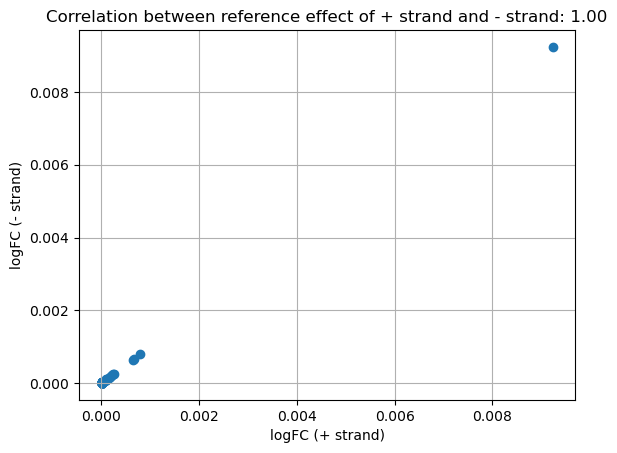

In [301]:
correlation_column = 'gnomad_AF'
correlation_column_plottable_name = 'reference effect'
# Separate the data into two groups based on the strand
plus_strand = same_variant_forward_reverse_bcalm[same_variant_forward_reverse_bcalm['strand'] == '+']
minus_strand = same_variant_forward_reverse_bcalm[same_variant_forward_reverse_bcalm['strand'] == '-']

if plus_strand.shape[0] != minus_strand.shape[0]:
    print("Unexpected difference in minus and plus strand observations")
# Merge the two groups on 'enformer_ID' to align the rows for correlation
merged_df = pd.merge(plus_strand[['enformer_ID', correlation_column]], minus_strand[['enformer_ID', correlation_column]], on='enformer_ID', suffixes=('_plus', '_minus'))
merged_df
# Calculate the correlation between  of '+' strand and '-' strand
correlation = merged_df[[correlation_column + '_plus', correlation_column + '_minus']].corr().iloc[0, 1]
correlation
# Plot the correlation
plt.scatter(merged_df[correlation_column + '_plus'], merged_df[correlation_column + '_minus'])
plt.xlabel('logFC (+ strand)')
plt.ylabel('logFC (- strand)')
plt.title(f'Correlation between {correlation_column_plottable_name} of + strand and - strand: {correlation:.2f}')
plt.grid(True)
plt.show()

##### Check if the alternative activity values correlate

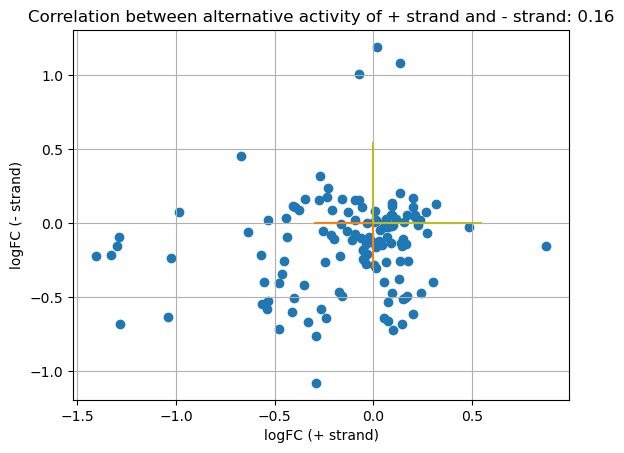

In [302]:
correlation_column = 'bcalm_alternative_log_ratio_activity'
correlation_column_plottable_name = 'alternative activity'
# Separate the data into two groups based on the strand
plus_strand = same_variant_forward_reverse_bcalm[same_variant_forward_reverse_bcalm['strand'] == '+']
minus_strand = same_variant_forward_reverse_bcalm[same_variant_forward_reverse_bcalm['strand'] == '-']

if plus_strand.shape[0] != minus_strand.shape[0]:
    print("Unexpected difference in minus and plus strand observations")
# Merge the two groups on 'enformer_ID' to align the rows for correlation
merged_df = pd.merge(plus_strand[['enformer_ID', correlation_column]], minus_strand[['enformer_ID', correlation_column]], on='enformer_ID', suffixes=('_plus', '_minus'))
merged_df
# Calculate the correlation between  of '+' strand and '-' strand
correlation = merged_df[[correlation_column + '_plus', correlation_column + '_minus']].corr().iloc[0, 1]
correlation
# Plot the correlation
plt.scatter(merged_df[correlation_column + '_plus'], merged_df[correlation_column + '_minus'])
plt.hlines(y=0, xmin=-0.3, xmax=0, colors="tab:orange")
plt.vlines(x=0, ymin=-0.3, ymax=0, colors="tab:orange")
plt.hlines(y=0, xmin=0, xmax=0.55, colors="tab:olive")
plt.vlines(x=0, ymin=0, ymax=0.55, colors="tab:olive")
plt.xlabel('logFC (+ strand)')
plt.ylabel('logFC (- strand)')
plt.title(f'Correlation between {correlation_column_plottable_name} of + strand and - strand: {correlation:.2f}')
plt.grid(True)
plt.show()

##### Check if the referece values correlate

for all variants: 

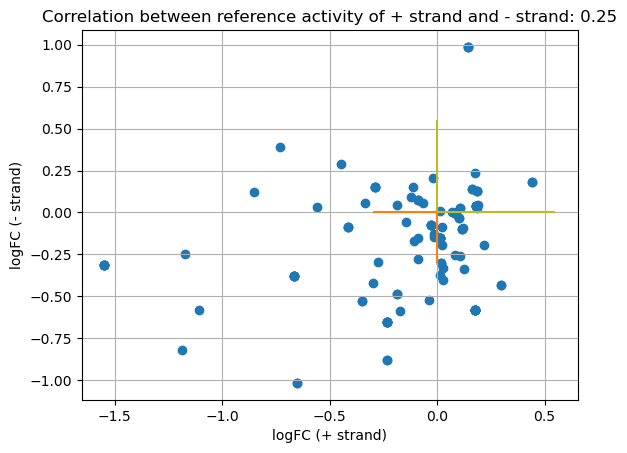

In [303]:
correlation_column = 'bcalm_reference_log_ratio_activity'
correlation_column_plottable_name = 'reference activity'
# Separate the data into two groups based on the strand
plus_strand = same_variant_forward_reverse_bcalm[same_variant_forward_reverse_bcalm['strand'] == '+']
minus_strand = same_variant_forward_reverse_bcalm[same_variant_forward_reverse_bcalm['strand'] == '-']

if plus_strand.shape[0] != minus_strand.shape[0]:
    print("Unexpected difference in minus and plus strand observations")
# Merge the two groups on 'enformer_ID' to align the rows for correlation
merged_df = pd.merge(plus_strand[['enformer_ID', correlation_column]], minus_strand[['enformer_ID', correlation_column]], on='enformer_ID', suffixes=('_plus', '_minus'))
merged_df
# Calculate the correlation between  of '+' strand and '-' strand
correlation = merged_df[[correlation_column + '_plus', correlation_column + '_minus']].corr().iloc[0, 1]
correlation
# Plot the correlation
plt.scatter(merged_df[correlation_column + '_plus'], merged_df[correlation_column + '_minus'])
plt.hlines(y=0, xmin=-0.3, xmax=0, colors="tab:orange")
plt.vlines(x=0, ymin=-0.3, ymax=0, colors="tab:orange")
plt.hlines(y=0, xmin=0, xmax=0.55, colors="tab:olive")
plt.vlines(x=0, ymin=0, ymax=0.55, colors="tab:olive")
plt.xlabel('logFC (+ strand)')
plt.ylabel('logFC (- strand)')
plt.title(f'Correlation between {correlation_column_plottable_name} of + strand and - strand: {correlation:.2f}')
plt.grid(True)
plt.show()

for active regions
- the reference effect seems to be the same for multiple variants => this is sus
- reference of 16-2039006-A-G, 16-2039121-G-A, 16-2039194-G-A (same reference + and - values)
- 0.141614071377946 ref +, 0.986210179064893 ref - 
- Check these in the cout matrix of the MPRAsnakeflow output => they have the same values for their reference because it is the same reference
    - 


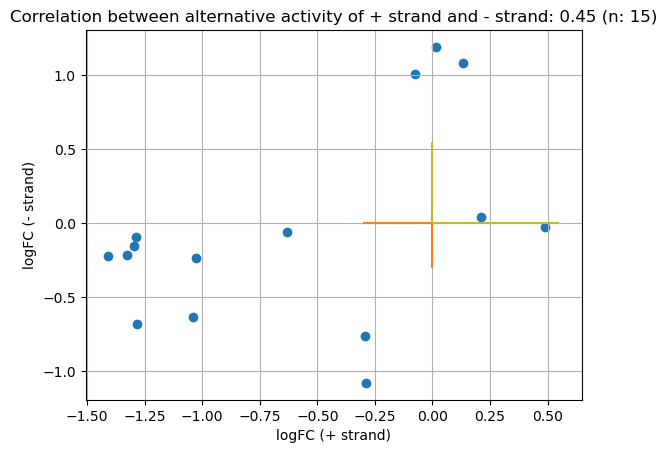

In [304]:
correlation_column = 'bcalm_alternative_log_ratio_activity'
correlation_column_plottable_name = 'alternative activity'
# correlation_column = 'bcalm_reference_log_ratio_activity'
# correlation_column_plottable_name = 'reference activity'
# correlation_column = 'bcalm_variant_effect_adjusted_p_value'
# correlation_column_plottable_name = 'variant p-Value'
# correlation_column = 'bcalm_variant_effect_log_ratio_activity'
# correlation_column_plottable_name = 'variant effect'
# Separate the data into two groups based on the strand
plus_strand = same_variant_forward_reverse_bcalm_active[same_variant_forward_reverse_bcalm_active['strand'] == '+']
minus_strand = same_variant_forward_reverse_bcalm_active[same_variant_forward_reverse_bcalm_active['strand'] == '-']

if plus_strand.shape[0] != minus_strand.shape[0]:
    print("Unexpected difference in minus and plus strand observations")
# Merge the two groups on 'enformer_ID' to align the rows for correlation
merged_df = pd.merge(plus_strand[['enformer_ID', correlation_column]], minus_strand[['enformer_ID', correlation_column]], on='enformer_ID', suffixes=('_plus', '_minus'))
merged_df
# Calculate the correlation between  of '+' strand and '-' strand
correlation = merged_df[[correlation_column + '_plus', correlation_column + '_minus']].corr().iloc[0, 1]
correlation
# Plot the correlation
plt.scatter(merged_df[correlation_column + '_plus'], merged_df[correlation_column + '_minus'])
plt.hlines(y=0, xmin=-0.3, xmax=0, colors="tab:orange")
plt.vlines(x=0, ymin=-0.3, ymax=0, colors="tab:orange")
plt.hlines(y=0, xmin=0, xmax=0.55, colors="tab:olive")
plt.vlines(x=0, ymin=0, ymax=0.55, colors="tab:olive")
plt.xlabel('logFC (+ strand)')
plt.ylabel('logFC (- strand)')
plt.title(f'Correlation between {correlation_column_plottable_name} of + strand and - strand: {correlation:.2f} (n: {merged_df["enformer_ID"].nunique()})')
plt.grid(True)
plt.show()

In [234]:
merged_df

,enformer_ID,bcalm_alternative_log_ratio_activity_plus,bcalm_alternative_log_ratio_activity_minus
0,16-2039006-A-G,-0.075195,1.009033
1,16-2039121-G-A,0.016179,1.192372
2,16-2039194-G-A,0.134563,1.084557
3,17-17790388-C-T,0.487257,-0.021826
4,17-17790429-G-A,0.210259,0.043266
5,19-46792231-A-T,-1.039049,-0.631254
6,19-54145729-C-T,-1.282206,-0.679489
7,7-150953140-C-T,-0.633395,-0.061516
8,7-151011075-G-C,-1.286969,-0.092986
9,7-151011114-G-A,-1.298374,-0.155217


In [235]:
same_variant_forward_reverse_bcalm_active[same_variant_forward_reverse_bcalm_active['strand'] == '+']

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,gnomad_AF,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj,enformer_ID,strand,variant_pos_element
16768,cardiac_neuro_cava_random:ALT_TSC2|ENSG0000010...,cardiac_neuro_cava_random:REF_TSC2|ENSG0000010...,cardiac_neuro_cava_random:ALT_TSC2|ENSG0000010...,GTTGCCTCGTAAGCCATAGCGCATGCGCGCTCTCAGGATAAACAGG...,GTTGCCTCGTAAGCCATAGCGCATGCGCGCTCTCAGGGTAAACAGG...,[37],True,0.775996,-0.220676,1.000000e+00,...,0.000026,0.000048,0.000000,0.000029,0.000000,0.000048,0.000000,16-2039006-A-G,+,37
16778,cardiac_neuro_cava_random:ALT_TSC2|ENSG0000010...,cardiac_neuro_cava_random:REF_TSC2|ENSG0000010...,cardiac_neuro_cava_random:ALT_TSC2|ENSG0000010...,GTTGCCTCGTAAGCCATAGCGCATGCGCGCTCTCAGGATAAACAGG...,GTTGCCTCGTAAGCCATAGCGCATGCGCGCTCTCAGGATAAACAGG...,[152],True,0.888944,-0.130811,1.000000e+00,...,0.000007,0.000015,0.000000,0.000015,0.000000,0.000000,0.000000,16-2039121-G-A,+,152
16782,cardiac_neuro_cava_random:ALT_TSC2|ENSG0000010...,cardiac_neuro_cava_random:REF_TSC2|ENSG0000010...,cardiac_neuro_cava_random:ALT_TSC2|ENSG0000010...,GTTGCCTCGTAAGCCATAGCGCATGCGCGCTCTCAGGATAAACAGG...,GTTGCCTCGTAAGCCATAGCGCATGCGCGCTCTCAGGATAAACAGG...,[225],True,0.992588,-0.011905,1.000000e+00,...,0.000026,0.000044,0.000000,0.000044,0.000000,0.000024,0.000000,16-2039194-G-A,+,225
20201,cardiac_neuro_cava_random:ALT_RAI1|ENSG0000010...,cardiac_neuro_cava_random:REF_RAI1|ENSG0000010...,cardiac_neuro_cava_random:ALT_RAI1|ENSG0000010...,CCTGGCTGGCACTGAGAGGCGGCCTGTGCCTTTGTTCCCATCCCTC...,CCTGGCTGGCACTGAGAGGCGGCCTGTGCCTTTGTTCCCATCCCTC...,[134],True,0.946109,0.039965,3.559097e-02,...,0.000020,0.000015,0.000000,0.000015,0.000000,0.000000,0.000576,17-17790388-C-T,+,134
20203,cardiac_neuro_cava_random:ALT_RAI1|ENSG0000010...,cardiac_neuro_cava_random:REF_RAI1|ENSG0000010...,cardiac_neuro_cava_random:ALT_RAI1|ENSG0000010...,CCTGGCTGGCACTGAGAGGCGGCCTGTGCCTTTGTTCCCATCCCTC...,CCTGGCTGGCACTGAGAGGCGGCCTGTGCCTTTGTTCCCATCCCTC...,[175],True,0.515688,-0.265967,3.559097e-02,...,0.000013,0.000386,0.000386,0.000000,0.000000,0.000000,0.000000,17-17790429-G-A,+,175
23597,cardiac_neuro_cava_random:ALT_FKRP|ENSG0000018...,cardiac_neuro_cava_random:REF_FKRP|ENSG0000018...,cardiac_neuro_cava_random:ALT_FKRP|ENSG0000018...,GTCAGCTGGAACTAAGCGTTGGGAGAAAGCAAAAGCATCCTATGAG...,GTCAGCTGGAACTAAGCGTTGGGAGAAAGCAAAAGCATCCTATGAG...,[146],True,0.952049,0.053382,6.332634e-04,...,0.000007,0.000207,0.000000,0.000000,0.000000,0.000000,0.000000,19-46792231-A-T,+,146
24060,cardiac_neuro_cava_random:ALT_CNOT3|ENSG000000...,cardiac_neuro_cava_random:REF_CNOT3|ENSG000000...,cardiac_neuro_cava_random:ALT_CNOT3|ENSG000000...,CAGGACCGGATTGAGGGCTTGAAGCGGCACATCGAGAAGCACCGCT...,CAGGACCGGATTGAGGGCTTGAAGCGGCACATCGAGAAGCACCGCT...,[128],True,0.844008,-0.178081,4.911921e-04,...,0.000085,0.000265,0.000000,0.000029,0.000000,0.000265,0.000000,19-54145729-C-T,+,128
41141,cardiac_neuro_cava_random:ALT_NOS3|ENSG0000016...,cardiac_neuro_cava_random:REF_NOS3|ENSG0000016...,cardiac_neuro_cava_random:ALT_NOS3|ENSG0000016...,CGACCACAGCAAATGGCCACCCCCAGGTTTGGGCATCATGGTTCCC...,CGACCACAGCAAATGGCCACCCCCAGGTTTGGGCATCATGGTTCCC...,[144],True,0.170825,0.569545,7.187382e-04,...,0.000644,0.001424,0.000000,0.000412,0.000753,0.001424,0.000000,7-150953140-C-T,+,144
41221,cardiac_neuro_cava_random:ALT_NOS3|ENSG0000016...,cardiac_neuro_cava_random:REF_NOS3|ENSG0000016...,cardiac_neuro_cava_random:ALT_NOS3|ENSG0000016...,CACGTGGCTAAGCCAGCTCAAGCCCGGAGACCCTGTGCCCTGCTTC...,CACGTGGCTAAGCCAGCTCAAGCCCGGAGACCCTGTGCCCTGCTTC...,[142],True,0.617191,0.376872,1.433039e-07,...,0.000033,0.000097,0.000000,0.000000,0.000000,0.000097,0.000000,7-151011075-G-C,+,142
41225,cardiac_neuro_cava_random:ALT_NOS3|ENSG0000016...,cardiac_neuro_cava_random:REF_NOS3|ENSG0000016...,cardiac_neuro_cava_random:ALT_NOS3|ENSG0000016...,CACGTGGCTAAGCCAGCTCAAGCCCGG

In [236]:
same_variant_forward_reverse_bcalm_active[same_variant_forward_reverse_bcalm_active['strand'] == '-']

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,gnomad_AF,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj,enformer_ID,strand,variant_pos_element
16769,cardiac_neuro_cava_random:ALT_NTHL1|ENSG000000...,cardiac_neuro_cava_random:REF_NTHL1|ENSG000000...,cardiac_neuro_cava_random:ALT_NTHL1|ENSG000000...,GGGCCCAGGATGTGCCACACAGCAGGGGGTCCCATGGGGGTCAGCG...,GGGCCCAGGATGTGCCACACAGCAGGGGGTCCCATGGGGGTCAGCG...,[232],True,0.990237,0.021031,0.000512,...,0.000026,0.000048,0.000000,0.000029,0.000000,0.000048,0.000000,16-2039006-A-G,-,232
16779,cardiac_neuro_cava_random:ALT_NTHL1|ENSG000000...,cardiac_neuro_cava_random:REF_NTHL1|ENSG000000...,cardiac_neuro_cava_random:ALT_NTHL1|ENSG000000...,GGGCCCAGGATGTGCCACACAGCAGGGGGTCCCATGGGGGTCAGCG...,GGGCCCAGGATGTGCCACACAGCAGGGGGTCCCATGGGGGTCAGCG...,[117],True,0.840307,0.203216,0.000512,...,0.000007,0.000015,0.000000,0.000015,0.000000,0.000000,0.000000,16-2039121-G-A,-,117
16783,cardiac_neuro_cava_random:ALT_NTHL1|ENSG000000...,cardiac_neuro_cava_random:REF_NTHL1|ENSG000000...,cardiac_neuro_cava_random:ALT_NTHL1|ENSG000000...,GGGCCCAGGATGTGCCACACAGCAGGGGGTCCCATGGGGGTCAGCG...,GGGCCCAGGATGTGCCACACAGCAGGGGGTCCCATGGGGGTCAGTG...,[44],True,0.943513,0.095013,0.000512,...,0.000026,0.000044,0.000000,0.000044,0.000000,0.000024,0.000000,16-2039194-G-A,-,44
20202,cardiac_neuro_cava_random:ALT_SREBF1|ENSG00000...,cardiac_neuro_cava_random:REF_SREBF1|ENSG00000...,cardiac_neuro_cava_random:ALT_SREBF1|ENSG00000...,TCTGCATTCCTCCCTCCCTGTTTAATTGGTCCAGCTGCTGTGTCTT...,TCTGCATTCCTCCCTCCCTGTTTAATTGGTCCAGCTGCTGTGTCTT...,[135],True,0.581379,-0.245862,1.000000,...,0.000020,0.000015,0.000000,0.000015,0.000000,0.000000,0.000576,17-17790388-C-T,-,135
20204,cardiac_neuro_cava_random:ALT_SREBF1|ENSG00000...,cardiac_neuro_cava_random:REF_SREBF1|ENSG00000...,cardiac_neuro_cava_random:ALT_SREBF1|ENSG00000...,TCTGCATTCCTCCCTCCCTGTTTAATTGGTCCAGCTGCTGTGTCTT...,TCTGCATTCCTCCCTCCCTGTTTAATTGGTCCAGCTGCTGTGTCTT...,[94],True,0.750262,-0.160668,1.000000,...,0.000013,0.000386,0.000386,0.000000,0.000000,0.000000,0.000000,17-17790429-G-A,-,94
23598,cardiac_neuro_cava_random:ALT_AP2S1|ENSG000000...,cardiac_neuro_cava_random:REF_AP2S1|ENSG000000...,cardiac_neuro_cava_random:ALT_AP2S1|ENSG000000...,TGCTTCCAAATCAGGAAAATGGGAGTGTGAGCTGGTCTCCTGGATT...,TGCTTCCAAATCAGGAAAATGGGAGTGTGAGCTGGTCTCCTGGATT...,[123],True,0.935503,-0.051126,1.000000,...,0.000007,0.000207,0.000000,0.000000,0.000000,0.000000,0.000000,19-46792231-A-T,-,123
24061,cardiac_neuro_cava_random:ALT_MBOAT7|ENSG00000...,cardiac_neuro_cava_random:REF_MBOAT7|ENSG00000...,cardiac_neuro_cava_random:ALT_MBOAT7|ENSG00000...,CAGCCCATTCTGGGCCCTCACTTCCTGTGCCACGATCAGCCCCAGG...,CAGCCCATTCTGGGCCCTCACTTCCTGTGCCACGATCAGCCCCAGG...,[141],True,0.844008,0.150288,0.509854,...,0.000085,0.000265,0.000000,0.000029,0.000000,0.000265,0.000000,19-54145729-C-T,-,141
41142,cardiac_neuro_cava_random:ALT_KCNH2|ENSG000000...,cardiac_neuro_cava_random:REF_KCNH2|ENSG000000...,cardiac_neuro_cava_random:ALT_KCNH2|ENSG000000...,TGCCCAGGTTGGGAGCTGTTGTCCTTGGAACCCTTTCCGGTCTGAG...,TGCCCAGGTTGGGAGCTGTTGTCCTTGGAACCCTTTCCGGTCTGAG...,[125],True,0.727653,0.179768,1.000000,...,0.000644,0.001424,0.000000,0.000412,0.000753,0.001424,0.000000,7-150953140-C-T,-,125
41222,cardiac_neuro_cava_random:ALT_KCNH2|ENSG000000...,cardiac_neuro_cava_random:REF_KCNH2|ENSG000000...,cardiac_neuro_cava_random:ALT_KCNH2|ENSG000000...,TCTGGGAGCTATAGTTTCAGGGCAGAACTCTGAGTCTAAATGAATG...,TCTGGGAGCTATAGTTTCAGGGCAGAACTCTGAGTCTAAATGAATG...,[127],True,0.687508,0.205006,1.000000,...,0.000033,0.000097,0.000000,0.000000,0.000000,0.000097,0.000000,7-151011075-G-C,-,127
41226,cardiac_neuro_cava_random:ALT_KCNH2|ENSG000000...,cardiac_neuro_cava_random:REF_KCNH2|ENSG000000...,cardiac_neuro_cava_random:ALT_KCNH2|ENSG000000...,TCTGGGAGCTATAGTTTCAGGGCAGAACTCTGAGTCTAAATGAATG...,TCTGGGAGCTATAGTTT

##### Check if the p-Values correlate

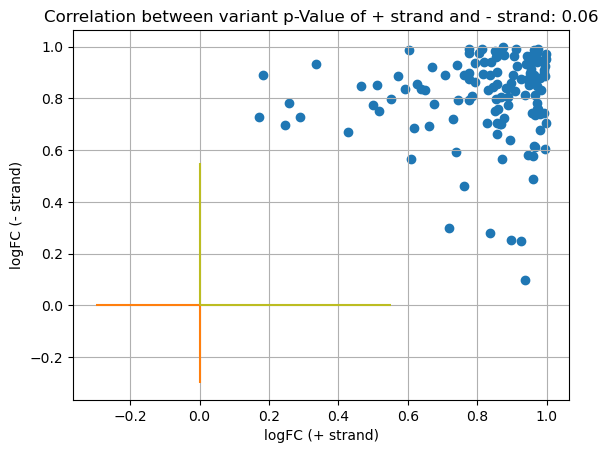

In [307]:
correlation_column = 'bcalm_variant_effect_adjusted_p_value'
correlation_column_plottable_name = 'variant p-Value'
# Separate the data into two groups based on the strand
plus_strand = same_variant_forward_reverse_bcalm[same_variant_forward_reverse_bcalm['strand'] == '+']
minus_strand = same_variant_forward_reverse_bcalm[same_variant_forward_reverse_bcalm['strand'] == '-']

if plus_strand.shape[0] != minus_strand.shape[0]:
    print("Unexpected difference in minus and plus strand observations")
# Merge the two groups on 'enformer_ID' to align the rows for correlation
merged_df = pd.merge(plus_strand[['enformer_ID', correlation_column]], minus_strand[['enformer_ID', correlation_column]], on='enformer_ID', suffixes=('_plus', '_minus'))
merged_df
# Calculate the correlation between  of '+' strand and '-' strand
correlation = merged_df[[correlation_column + '_plus', correlation_column + '_minus']].corr().iloc[0, 1]
correlation
# Plot the correlation
plt.scatter(merged_df[correlation_column + '_plus'], merged_df[correlation_column + '_minus'])
plt.hlines(y=0, xmin=-0.3, xmax=0, colors="tab:orange")
plt.vlines(x=0, ymin=-0.3, ymax=0, colors="tab:orange")
plt.hlines(y=0, xmin=0, xmax=0.55, colors="tab:olive")
plt.vlines(x=0, ymin=0, ymax=0.55, colors="tab:olive")
plt.xlabel('logFC (+ strand)')
plt.ylabel('logFC (- strand)')
plt.title(f'Correlation between {correlation_column_plottable_name} of + strand and - strand: {correlation:.2f}')
plt.grid(True)
plt.show()

##### Check if the variant effect correlates

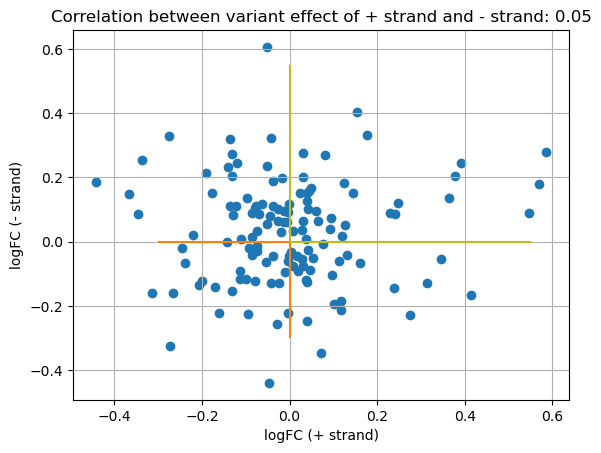

In [310]:
correlation_column = 'bcalm_variant_effect_log_ratio_activity'
correlation_column_plottable_name = 'variant effect'
# Separate the data into two groups based on the strand
plus_strand = same_variant_forward_reverse_bcalm[same_variant_forward_reverse_bcalm['strand'] == '+']
minus_strand = same_variant_forward_reverse_bcalm[same_variant_forward_reverse_bcalm['strand'] == '-']

if plus_strand.shape[0] != minus_strand.shape[0]:
    print("Unexpected difference in minus and plus strand observations")
# Merge the two groups on 'enformer_ID' to align the rows for correlation
merged_df = pd.merge(plus_strand[['enformer_ID', correlation_column]], minus_strand[['enformer_ID', correlation_column]], on='enformer_ID', suffixes=('_plus', '_minus'))
merged_df
# Calculate the correlation between bcalm_variant_effect_log_ratio_activity of '+' strand and '-' strand
correlation = merged_df[[correlation_column + '_plus', correlation_column + '_minus']].corr(method="pearson").iloc[0, 1]
correlation
# Plot the correlation
plt.scatter(merged_df[correlation_column + '_plus'], merged_df[correlation_column + '_minus'])
plt.hlines(y=0, xmin=-0.3, xmax=0, colors="tab:orange")
plt.vlines(x=0, ymin=-0.3, ymax=0, colors="tab:orange")
plt.hlines(y=0, xmin=0, xmax=0.55, colors="tab:olive")
plt.vlines(x=0, ymin=0, ymax=0.55, colors="tab:olive")
plt.xlabel('logFC (+ strand)')
plt.ylabel('logFC (- strand)')
plt.title(f'Correlation between {correlation_column_plottable_name} of + strand and - strand: {correlation:.2f}')
plt.grid(True)
plt.show()

In [239]:
filtered_duplicates.shape[0]

1238

### Get the rarety class from gnomad info and plot the number and proportion of significant variants

In [13]:
def get_variant_rarety_class(row, af_col="gnomad_AF", ac_col="gnomad_AC"):
    """Variant rarety class:
    if ac==1: singleton:
    if af <= 1% ultra-rare
    if af >5% common
    if af >1% rare
    """
    variant_af = row[af_col]
    variant_ac = row[ac_col]
    if variant_ac == 1:
        return "singleton"
    elif variant_af <= 0.01:
        return "ultra-rare"
    elif variant_af >= 0.05:
        return "common"
    elif variant_af > 0.01:
        return "rare"



In [39]:
variant_bcalm_metadata_df_gnomad_info['variant_rarety_class'] = variant_bcalm_metadata_df_gnomad_info.apply(lambda row: get_variant_rarety_class(row, af_col="gnomad_AF", ac_col="gnomad_AC"), axis=1)

In [40]:
variant_bcalm_metadata_df_gnomad_info['variant_rarety_class'].value_counts()

variant_rarety_class
ultra-rare    12236
common        12145
singleton     12137
rare           9856
Name: count, dtype: int64

In [41]:
variant_bcalm_exists_metadata_df_gnomad_info = variant_bcalm_metadata_df_gnomad_info.loc[variant_bcalm_metadata_df_gnomad_info['bcalm_variant_effect_data_exists']].copy()

In [42]:
variant_bcalm_exists_metadata_df_gnomad_info['variant_rarety_class'].value_counts()

variant_rarety_class
singleton     10104
ultra-rare    10045
common         9836
rare           7885
Name: count, dtype: int64

In [43]:
variant_bcalm_metadata_df_gnomad_info.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_header',
       'gnomad_chrom', 'gnomad_pos', 'gnomad_ref', 'gnomad_alt', 'gnomad_AC',
       'gnomad_AF', 'gnomad_AF_popmax', 'gnomad_AF_eas', 'gnomad_AF_nfe',
       'gnomad_AF_fin', 'gnomad_AF_afr', 'gnomad_AF_asj', 'enformer_ID',
       'variant_rarety_class'],
      dtype='object')

In [44]:
variant_bcalm_exists_metadata_df_gnomad_info["variant_rarety_class"].shape[0]

37870

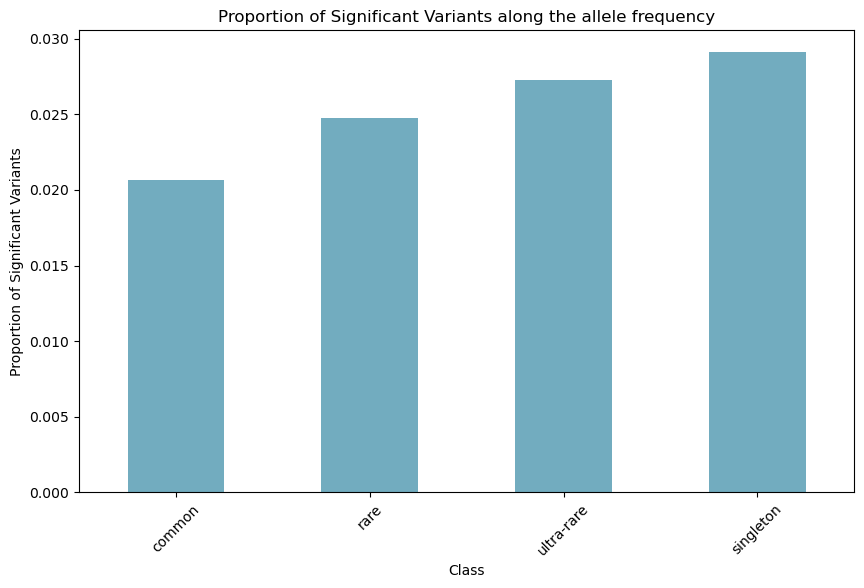

In [45]:

total_counts = variant_bcalm_exists_metadata_df_gnomad_info.groupby("variant_rarety_class").size()

# Compute the number of significant variants for each class
significant_counts = variant_bcalm_exists_metadata_df_gnomad_info[variant_bcalm_exists_metadata_df_gnomad_info["bcalm_variant_effect_adjusted_p_value"] < 0.05].groupby("variant_rarety_class").size()
custom_order = ["common", "rare", "ultra-rare", "singleton"]  # Adjust this list as needed
proportion_significant = significant_counts / total_counts

proportion_significant = proportion_significant.reindex(custom_order)
# Plotting the results
plt.figure(figsize=(10, 6))
proportion_significant.plot(kind='bar', color='#72ACBF')
plt.xlabel('Class')
plt.ylabel('Proportion of Significant Variants')
plt.title('Proportion of Significant Variants along the allele frequency')
plt.xticks(rotation=45)
plt.show()

### Volcano plot and number of variants: 

In [46]:
print(f"Number and proportion of significant variants: {variant_bcalm_exists_metadata_df_gnomad_info.loc[variant_bcalm_exists_metadata_df_gnomad_info['bcalm_variant_effect_adjusted_p_value'] < 0.1].shape[0]}")
variant_bcalm_exists_metadata_df_gnomad_info.loc[variant_bcalm_exists_metadata_df_gnomad_info["bcalm_variant_effect_adjusted_p_value"] < 0.1].shape[0]/variant_bcalm_exists_metadata_df_gnomad_info.loc[variant_bcalm_exists_metadata_df_gnomad_info["bcalm_variant_effect_data_exists"]].shape[0]

Number and proportion of significant variants: 1304


0.03443358859255347

In [47]:
variant_bcalm_exists_metadata_df_gnomad_info.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_header',
       'gnomad_chrom', 'gnomad_pos', 'gnomad_ref', 'gnomad_alt', 'gnomad_AC',
       'gnomad_AF', 'gnomad_AF_popmax', 'gnomad_AF_eas', 'gnomad_AF_nfe',
       'gnomad_AF_fin', 'gnomad_AF_afr', 'gnomad_AF_asj', 'enformer_ID',
       'variant_rarety_class'],
      dtype='object')

In [48]:
def plot_vulcano(MPRAlm_table, title, ylim_max=35, ylim_min=-0.025, xlim_min=-4, xlim_max=4, sig_dot_size=3):
    significants_niveau = 0.1
    logFC_col = 'bcalm_variant_effect_log_ratio_activity'
    adj_pValue = "bcalm_variant_effect_adjusted_p_value"
    MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table[logFC_col] > 0) & (MPRAlm_table[adj_pValue] < significants_niveau), 'positive', 'neutral')
    MPRAlm_table['mpralm_true'] = np.where((MPRAlm_table[logFC_col] < 0) & (MPRAlm_table[adj_pValue] < significants_niveau), 'negative', MPRAlm_table['mpralm_true'])

    significant_MPRAlm_table = MPRAlm_table[MPRAlm_table[adj_pValue] < significants_niveau]
    up = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'positive']
    down = MPRAlm_table[MPRAlm_table['mpralm_true'] == 'negative']

    plt.figure(figsize=(15,10))
    # make background dark for the plot
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    ax = plt.gca()
    plt.style.use("ggplot")
    plt.scatter(x=MPRAlm_table[logFC_col],y=MPRAlm_table[adj_pValue].apply(lambda x:-np.log10(x)),s=1,label=f"MPRAlm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
    plt.scatter(x=down[logFC_col],y=down[adj_pValue].apply(lambda x:-np.log10(x)),s=sig_dot_size,label="MPRAlm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
    plt.scatter(x=up[logFC_col],y=up[adj_pValue].apply(lambda x:-np.log10(x)),s=sig_dot_size,label="MPRAlm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
    # scatter for controls
    # plt.scatter()


    # Keep x-axis between -4, 4
    # keep y-axis between 0, 4
    ax.set_xlim([xlim_min,xlim_max])
    ax.set_ylim([ylim_min,ylim_max])
    # increase font size
    plt.rcParams.update({'font.size': 15})
    # increase font size of labels and ticks
    plt.tick_params(axis='both', which='major', labelsize=15)
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    plt.style.use("ggplot")
    plt.xlabel("logFC")
    plt.ylabel("-logFDR")
    plt.axhline(1,color="grey",linestyle="--")
    plt.title(title)
    plt.legend()
    plt.show()

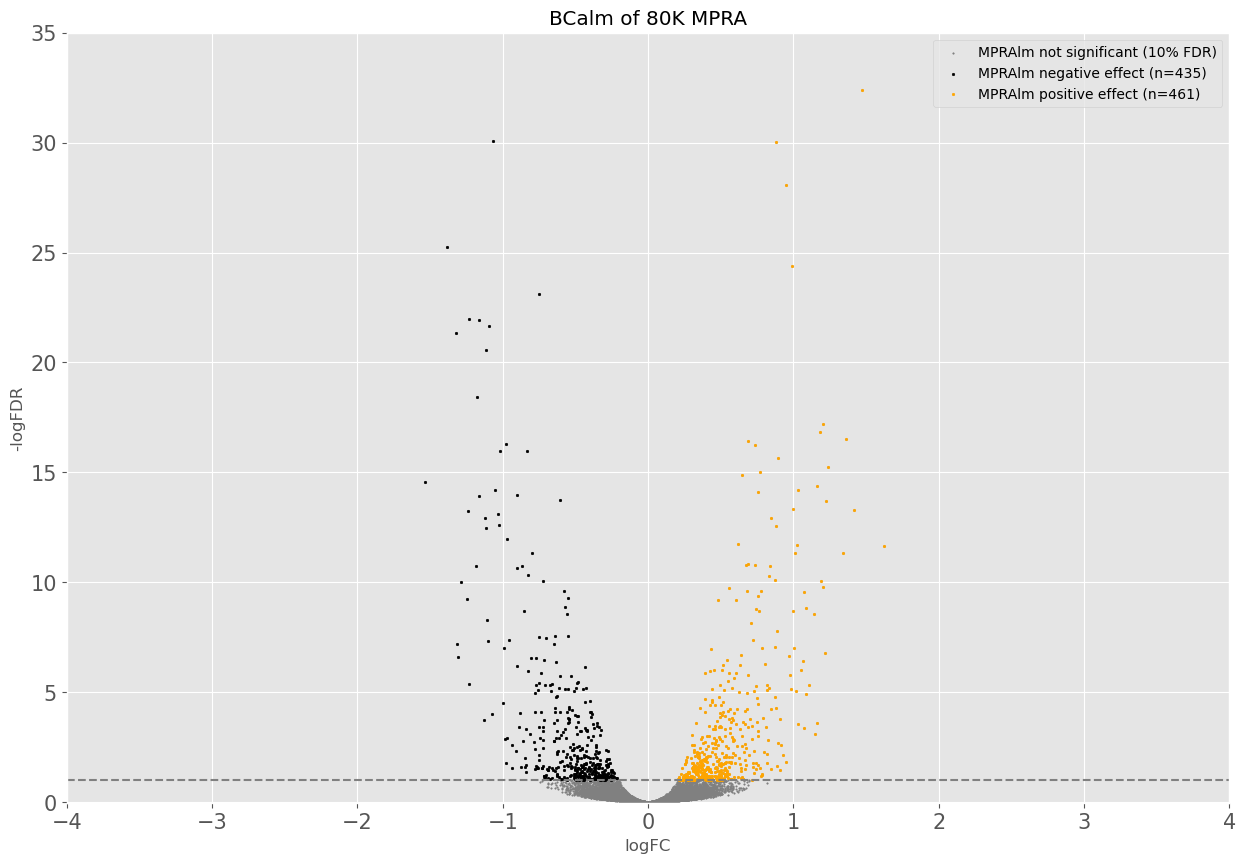

896

In [ ]:
# plot_vulcano(bcMPRAlm_table_no_downsampling, title="barcode MPRAlm No downsampling")
plot_vulcano(variant_bcalm_exists_metadata_df_gnomad_info, title="BCalm of 80K MPRA")


In [49]:
total_counts

variant_rarety_class
common         9836
rare           7885
singleton     10104
ultra-rare    10045
dtype: int64

In [50]:
proportion_significant

variant_rarety_class
common        0.020638
rare          0.024731
ultra-rare    0.027277
singleton     0.029097
dtype: float64

### Focus on ultra-rare and singleton for the prioritization
- in oder to merge the information we can use the variant identifier chr pos ref alt but we need to resample the random class

In [51]:
# helpful functions
def get_variant_type(AF, AC):
    """
    get ultra-rare, common, singleton from INFO: 'AF=0.0126802;AC=1930' => common
    """
    if AF > 0.05:
        return 'common'
    elif AF > 0.01:
        return 'rare'
    elif AC == 1:
        return 'singleton'
    else:
        return 'ulra-rare'


def get_gene_lookup_dict(gene_lists):
    """
    prepare a dict which has gene_name: (list of associated gene_sets)
    :gene_lists - list of files containing gene names and have useful names
    """
    gene_lookup_dict = defaultdict(list)
    for file in gene_lists:
        with open(os.path.join(gene_list_dir, file), 'r') as f:
            gene_list = f.read().splitlines()
            gene_list_name = file.split('.')[0]
            for gene in gene_list:
                gene_lookup_dict[gene].append(gene_list_name)
    return gene_lookup_dict


def has_variant_info_in_header(header):
    """Check if the header has the variant info (chr-pos-ref-alt) in the ending of the header"""
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return True
    else: return False


def get_chrom_pos_ref_alt_pattern(header):
    """
    In the 80K MPRA design each variant has a chr-pos-ref-alt pattern in the header
    This function is able to match it and returns the result
    """
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return matches.group()
    else: return "NA"


# investigating variant (enformer) metadata file
def get_enformer_class_list(enformer_variant_info):
    """
    return the enformer class list
    enformer_variant_info: [('gene_set', 'variant_type', 'enformer_class'), ]
    """
    enformer_class_list = []
    for elem in enformer_variant_info:
        enformer_class_list.append(elem[2])
    return list(set(enformer_class_list))


def get_variant_type_list(enformer_variant_info):
    """
    return the variant type list
    enformer_variant_info: [('gene_set', 'variant_type', 'enformer_class'), ]
    """
    variant_type_list = []
    for elem in enformer_variant_info:
        variant_type_list.append(elem[1])
    return list(set(variant_type_list))


def get_gene_set_list(enformer_variant_info):
    """
    return the geme set list
    enformer_variant_info: [('gene_set', 'variant_type', 'enformer_class'), ]
    """
    gene_set_list = []
    for elem in enformer_variant_info:
        gene_set_list.append(elem[0])
    return list(set(gene_set_list))


# # sanity checking the gene_lists genes
# def get_all_gene_lists_genes(gene_lists):
#     all_genes = []
#     for file in gene_lists:
#         with open(os.path.join(gene_list_dir, file), 'r') as f:
#             gene_list = f.read().splitlines()
#             gene_list_name = file.split('.')[0]
#             for gene in gene_list:
#                 all_genes.append(gene)
#     return all_genes


# def is_element_of(column_list, pattern):
#     """Check for the pattern in the column_list"""
#     return pattern in column_list

In [52]:
variant_bcalm_exists_metadata_df_gnomad_info['variant_type_annotation'] = variant_bcalm_exists_metadata_df_gnomad_info.apply(lambda row: get_variant_type(row['gnomad_AF'], row['gnomad_AC']), axis=1)

In [58]:
print("Number of variants with bcalm info: ", variant_bcalm_exists_metadata_df_gnomad_info.shape[0])
variant_bcalm_exists_metadata_df_gnomad_info['variant_type_annotation'].value_counts()

Number of variants with bcalm info:  37870


variant_type_annotation
singleton    10104
ulra-rare    10045
common        9836
rare          7885
Name: count, dtype: int64

In [59]:
from ast import literal_eval
common_enformer_varaint_df = pd.read_csv(config['files']['creating']['common_and_enformer_variants'], sep="\t")
common_enformer_varaint_df['chr_pos_ref_alt'] = common_enformer_varaint_df['ID'].apply(get_chrom_pos_ref_alt_pattern)
common_enformer_varaint_df['enformer_variant_info'] = common_enformer_varaint_df['enformer_variant_info'].apply(literal_eval)
common_enformer_varaint_df['enformer_class_list'] = common_enformer_varaint_df['enformer_variant_info'].apply(get_enformer_class_list)
common_enformer_varaint_df['gene_set_list'] = common_enformer_varaint_df['enformer_variant_info'].apply(get_gene_set_list)
common_enformer_varaint_df['variant_type_list'] = common_enformer_varaint_df['enformer_variant_info'].apply(get_variant_type_list)
print(common_enformer_varaint_df.shape[0])
# # drop duplicates based on chr_pos_ref_alt
# unique_variants = common_enformer_varaint_df.drop_duplicates(subset=['chr_pos_ref_alt'])
# unique_variants.shape # 68222 more than in the final design which makes sense

68222


In [60]:
common_enformer_varaint_df

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list
0,chr1,2177753,SKI|ENSG00000157933.11|EH38E2778468|1-2177753-C-T,C,T,1,PASS,AF=0.0126802;AC=1930,1-2177753-C-T,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare]
1,chr1,2180660,SKI|ENSG00000157933.11|EH38E2778473|1-2180660-T-C,T,C,1,PASS,AF=0.0143032;AC=2175,1-2180660-T-C,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare]
2,chr1,2182832,SKI|ENSG00000157933.11|EH38E2778478|1-2182832-C-T,C,T,1,PASS,AF=0.0450113;AC=6841,1-2182832-C-T,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare]
3,chr1,2191284,SKI|ENSG00000157933.11|EH38E2778490|1-2191284-C-G,C,G,1,PASS,AF=0.046652;AC=7101,1-2191284-C-G,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare]
4,chr1,2191444,SKI|ENSG00000157933.11|EH38E2778490|1-2191444-G-A,G,A,1,PASS,AF=0.0172033;AC=2617,1-2191444-G-A,NaN,NaN,"[(neuro, rare, NA)]",[NA],[neuro],[rare]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68217,chr2,219219689,ANKZF1|ENSG00000163516.14|EH38E3401197|2-21921...,T,G,1,PASS,AF=1.97075e-05;AC=3,2-219219689-T-G,-0.586787,31_DNASE:iPS-NIHi11 mal,"[(random, ultra-rare, enformer_low)]",[enformer_low],[random],[ultra-rare]
68218,chr19,48747089,IZUMO1|ENSG00000182264.9|EH38E1960256|19-48747...,C,T,1,PASS,AF=1.31413e-05;AC=2,19-48747089-C-T,-0.961862,90_DNASE:HeLa-S3 G1b ph,"[(random, ultra-rare, enformer_low)]",[enformer_low],[random],[ultra-rare]
68219,chr2,210475933,CPS1|ENSG00000021826.18|EH38E3397490|2-2104759...,C,A,1,PASS,AF=2.62871e-05;AC=4,2-210475933-C-A,-0.964058,665_DNASE:testis male ad,"[(random, ultra-rare, enformer_low)]",[enformer_low],[random],[ultra-rare]
68220,chr2,210477091,CPS1|ENSG00000021826.18|EH38E3397493|2-2104770...,C,T,1,PASS,AF=7.60025e-05;AC=11,2-210477091-C-T,-1.122092,170_DNASE:iPS DF 4.7 mal,"[(random, ultra-rare, enformer_low)]",[enformer_low],[random],[ultra-rare]


In [61]:
# get only data with enformer class (no common variants)
enformer_class_df = common_enformer_varaint_df.loc[~common_enformer_varaint_df['DNase_max'].isna()]

# Explode the list of tuples into separate rows
df_exploded = enformer_class_df.explode('enformer_variant_info')

# Split the tuples into separate columns
df_exploded[['gene_set', 'variant_type', 'enformer_class']] = pd.DataFrame(df_exploded['enformer_variant_info'].tolist(), index=df_exploded.index)

# Perform a simple groupby operation as an example (e.g., count occurrences)
grouped_df = df_exploded.groupby(['gene_set','variant_type']).size().reset_index(name='counts')

# Display the grouped DataFrame
print(grouped_df)
#   gene_set variant_type  counts
# 0  cardiac    singleton    5000
# 1  cardiac   ultra-rare    5000
# 2     cava    singleton    5000
# 3     cava   ultra-rare    5000
# 4    neuro    singleton    5000
# 5    neuro   ultra-rare    5000
# 6   random    singleton    2500
# 7   random   ultra-rare    2500
grouped_df_enformer_class = df_exploded.groupby(['gene_set','variant_type', 'enformer_class']).size().reset_index(name='counts')

  gene_set variant_type  counts
0  cardiac    singleton    5000
1  cardiac   ultra-rare    5000
2     cava    singleton    5000
3     cava   ultra-rare    5000
4    neuro    singleton    5000
5    neuro   ultra-rare    5000
6   random    singleton    2500
7   random   ultra-rare    2500


In [62]:
enformer_class_df.shape[0]

34100

In [63]:
print(grouped_df_enformer_class)

   gene_set variant_type   enformer_class  counts
0   cardiac    singleton    enformer_high    3500
1   cardiac    singleton     enformer_low     750
2   cardiac    singleton  enformer_random     750
3   cardiac   ultra-rare    enformer_high    3500
4   cardiac   ultra-rare     enformer_low     750
5   cardiac   ultra-rare  enformer_random     750
6      cava    singleton    enformer_high    3500
7      cava    singleton     enformer_low     750
8      cava    singleton  enformer_random     750
9      cava   ultra-rare    enformer_high    3500
10     cava   ultra-rare     enformer_low     750
11     cava   ultra-rare  enformer_random     750
12    neuro    singleton    enformer_high    3500
13    neuro    singleton     enformer_low     750
14    neuro    singleton  enformer_random     750
15    neuro   ultra-rare    enformer_high    3500
16    neuro   ultra-rare     enformer_low     750
17    neuro   ultra-rare  enformer_random     750
18   random    singleton    enformer_high    1750


In [64]:
df_exploded_neuro = df_exploded.loc[df_exploded["gene_set"] == "neuro"].copy()


In [65]:
df_exploded_neuro.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO',
       'chr_pos_ref_alt', 'DNase_max', 'max_col', 'enformer_variant_info',
       'enformer_class_list', 'gene_set_list', 'variant_type_list', 'gene_set',
       'variant_type', 'enformer_class'],
      dtype='object')

In [66]:
df_exploded_neuro["enformer_class"].value_counts()

enformer_class
enformer_high      7000
enformer_low       1500
enformer_random    1500
Name: count, dtype: int64

In [ ]:
# for every combination of neuro singleton, neuro ultra-rare, cava singleton, cava ultra-rare, cardiac singleton, cardiac ultra-rare, random singleton, random ultra-rare

In [67]:
gene_group = None
variant_class_list = None
variant_class_counter = None


In [69]:
import pandas as pd
import numpy as np

gene_group_variant_number = {
    "neuro": [598537, 607227],
    "cardiac": [289724, 296173],
    "cava": [69363, 69286],
    "random": [23216, 24397]
}

# gene_group = "neuro"
number_idx = 0
variant_class_list = ["ultra-rare", "singleton"]
variant_class_counter = 0
for gene_group, gene_group_variant_numbers in gene_group_variant_number.items():
    print(gene_group)
    for variant_class in variant_class_list:
        print(variant_class)
        variant_class_idx = variant_class_counter % 2
        df_exploded_gene_group = df_exploded.loc[df_exploded["gene_set"] == gene_group].copy()
        # split into ultra-rare and singleton
        df_exploded_gene_group_variant_class = df_exploded_gene_group.loc[df_exploded_gene_group["variant_type"] == variant_class].copy()
        # ultra rare size: 598537
        # singleton size: 607227


        # Count number of rows per group
        high_count = (df_exploded_gene_group_variant_class["enformer_class"] == "enformer_high").sum()
        low_count = (df_exploded_gene_group_variant_class["enformer_class"] == "enformer_low").sum()
        random_count = (df_exploded_gene_group_variant_class["enformer_class"] == "enformer_random").sum()

        # sample the amount of enformer high and enformer low which was not available for the random sampling
        # => e.g. number of high / all variants considered (for ultra-rare: 598537)
        # high_count/598537 * high_count
        # # Compute the number of samples to take
        num_high_sample = math.ceil(high_count/gene_group_variant_numbers[variant_class_idx] * high_count)
        num_low_sample = math.ceil(low_count/gene_group_variant_numbers[variant_class_idx] * low_count)
        num_total_sample = num_high_sample + num_low_sample  # This is the amount to remove from "random"
        num_total_sample # 22

        # Sample from "high" and "low" groups
        high_sample = df_exploded_gene_group_variant_class[df_exploded_gene_group_variant_class["enformer_class"] == "enformer_high"].sample(n=num_high_sample, random_state=42).index
        low_sample = df_exploded_gene_group_variant_class[df_exploded_gene_group_variant_class["enformer_class"] == "enformer_low"].sample(n=num_low_sample, random_state=42).index

        # Sample from "random" to be deleted
        random_sample = df_exploded_gene_group_variant_class[df_exploded_gene_group_variant_class["enformer_class"] == "enformer_random"].sample(n=num_total_sample, random_state=42).index

        # Create a new column and assign the new labels
        df_exploded_gene_group_variant_class["new_enformer_class"] = df_exploded_gene_group_variant_class["enformer_class"]  # Start with the same group
        df_exploded_gene_group_variant_class.loc[high_sample, "new_enformer_class"] = "enformer_random"
        df_exploded_gene_group_variant_class.loc[low_sample, "new_enformer_class"] = "enformer_random"
        df_exploded_gene_group_variant_class.loc[random_sample, "new_enformer_class"] = "deleted"

        # Display result
        df_exploded_gene_group_variant_class["new_enformer_class"].value_counts()


        output_name = f"enformer_prio_class_adjusted_random_with_deleted_class_{gene_group}_{variant_class}.tsv"
        output_dir = "/home/kisa/coding/80K_MPRA/enformer_data/adjusted_random_sampling"
        print(output_name)
        if df_exploded_gene_group_variant_class.shape[0] == df_exploded_gene_group_variant_class["chr_pos_ref_alt"].nunique():
            print("variants in this group are unique")
        else:
            print("variants in this group are not unique")

        if write_output:
            df_exploded_gene_group_variant_class.to_csv(os.path.join(output_dir, output_name), sep="\t", index=False)
        variant_class_counter += 1

neuro
ultra-rare
enformer_prio_class_adjusted_random_with_deleted_class_neuro_ultra-rare.tsv
variants in this group are unique
singleton
enformer_prio_class_adjusted_random_with_deleted_class_neuro_singleton.tsv
variants in this group are unique
cardiac
ultra-rare
enformer_prio_class_adjusted_random_with_deleted_class_cardiac_ultra-rare.tsv
variants in this group are unique
singleton
enformer_prio_class_adjusted_random_with_deleted_class_cardiac_singleton.tsv
variants in this group are unique
cava
ultra-rare
enformer_prio_class_adjusted_random_with_deleted_class_cava_ultra-rare.tsv
variants in this group are unique
singleton
enformer_prio_class_adjusted_random_with_deleted_class_cava_singleton.tsv
variants in this group are unique
random
ultra-rare
enformer_prio_class_adjusted_random_with_deleted_class_random_ultra-rare.tsv
variants in this group are unique
singleton
enformer_prio_class_adjusted_random_with_deleted_class_random_singleton.tsv
variants in this group are unique


In [70]:
df_exploded_gene_group_variant_class

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,gene_set,variant_type,enformer_class,new_enformer_class
63222,chr19,48760989,IZUMO1|ENSG00000182264.9|EH38E1960273|19-48760...,G,C,1,PASS,AF=6.57082e-06;AC=1,19-48760989-G-C,3024.686800,392_DNASE:CD14-positive,"(random, singleton, enformer_high)",[enformer_high],[random],[singleton],random,singleton,enformer_high,enformer_high
63223,chr22,22681559,IGLV3-25|ENSG00000211659.2|EH38E3470207|22-226...,G,C,1,PASS,AF=6.58363e-06;AC=1,22-22681559-G-C,2225.757600,625_DNASE:K562,"(random, singleton, enformer_high)",[enformer_high],[random],[singleton],random,singleton,enformer_high,enformer_high
63224,chr22,22681539,IGLV3-25|ENSG00000211659.2|EH38E3470207|22-226...,G,A,1,PASS,AF=6.58363e-06;AC=1,22-22681539-G-A,2223.745000,625_DNASE:K562,"(random, singleton, enformer_high)",[enformer_high],[random],[singleton],random,singleton,enformer_high,enformer_high
63225,chr4,108036421,HADH|ENSG00000138796.18|EH38E3599017|4-1080364...,T,G,1,PASS,AF=6.5767e-06;AC=1,4-108036421-T-G,1864.680500,"177_DNASE:CD8-positive,","(random, singleton, enformer_high)",[enformer_high],[random],[singleton],random,singleton,enformer_high,enformer_high
63226,chr19,48748141,IZUMO1|ENSG00000182264.9|EH38E3312608|19-48748...,C,T,1,PASS,AF=6.57341e-06;AC=1,19-48748141-C-T,1828.968900,588_DNASE:hematopoietic,"(random, singleton, enformer_high)",[enformer_high],[random],[singleton],random,singleton,enformer_high,enformer_high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65717,chr6,26284345,H1-3|ENSG00000124575.7|EH38E3697740|6-26284345...,G,A,1,PASS,AF=6.57903e-06;AC=1,6-26284345-G-A,-0.157125,654_DNASE:HeLa-S3,"(random, singleton, enformer_low)",[enformer_low],[random],[singleton],random,singleton,enformer_low,enformer_low
65718,chr2,210478202,CPS1|ENSG00000021826.18|EH38E3397495|2-2104782...,C,T,1,PASS,AF=6.5697e-06;AC=1,2-210478202-C-T,-0.164823,665_DNASE:testis male ad,"(random, singleton, enformer_low)",[enformer_low],[random],[singleton],random,singleton,enformer_low,enformer_low
65719,chr2,210477975,CPS1|ENSG00000021826.18|EH38E3397495|2-2104779...,G,C,1,PASS,AF=6.57315e-06;AC=1,2-210477975-G-C,-0.276388,534_DNASE:vagina female,"(random, singleton, enformer_low)",[enformer_low],[random],[singleton],random,singleton,enformer_low,enformer_low
65720,chr2,210478142,CPS1|ENSG00000021826.18|EH38E3397495|2-2104781...,T,A,1,PASS,AF=6.56858e-06;AC=1,2-210478142-T-A,-0.400148,26_DNASE:hepatocyte,"(random, singleton, enformer_low)",[enformer_low],[random],[singleton],random,singleton,enformer_low,enformer_low


In [71]:
# concat all files and compute the enrichment
from os import listdir
path_to_enformer_files = "/home/kisa/coding/80K_MPRA/enformer_data/adjusted_random_sampling"
all_enformer_prioritization_files = [os.path.join(path_to_enformer_files, file) for file in listdir(path_to_enformer_files) if file.startswith("enformer_prio_class_")]
all_enformer_prio_df = pd.concat([pd.read_csv(file, sep="\t", low_memory=False) for file in all_enformer_prioritization_files])

In [72]:
all_enformer_prio_df['chr_pos_ref_alt'].nunique()

# 34100 => 900 duplicates
all_enformer_prio_df.loc[all_enformer_prio_df.duplicated(subset=['chr_pos_ref_alt'], keep=False)].sort_values(by="chr_pos_ref_alt")

# is id + gene set unique? - yes
all_enformer_prio_df.loc[all_enformer_prio_df.duplicated(subset=['chr_pos_ref_alt', 'gene_set'], keep=False)].sort_values(by="chr_pos_ref_alt")

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,gene_set,variant_type,enformer_class,new_enformer_class


In [137]:
all_enformer_prio_df['chr_pos_ref_alt'].nunique()

34100

In [131]:
# check if the new enformer group is within the duplicates
duplicated_enformer_values = all_enformer_prio_df.loc[all_enformer_prio_df.duplicated(subset=['chr_pos_ref_alt'], keep=False)].sort_values(by="chr_pos_ref_alt") # 1,759
print("Number of duplicated variants: ", duplicated_enformer_values['chr_pos_ref_alt'].nunique())
varaint_has_same_enformer_group = duplicated_enformer_values.groupby(["chr_pos_ref_alt"])["new_enformer_class"].nunique().eq(1).reset_index(name="same_enformer_class") # 35

duplicated_enformer_values_different_enformer_class = duplicated_enformer_values.merge(varaint_has_same_enformer_group, on="chr_pos_ref_alt", how="inner")
duplicates_different_enformer_class = duplicated_enformer_values_different_enformer_class.loc[~duplicated_enformer_values_different_enformer_class["same_enformer_class"]]
duplicates_different_enformer_class # 73

Number of duplicated variants:  859


,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,gene_set,variant_type,enformer_class,new_enformer_class,same_enformer_class
52,chr1,156100589,LMNA|ENSG00000160789.24|EH38E1387613|1-1561005...,G,A,1,PASS,AF=6.57298e-06;AC=1,1-156100589-G-A,513.31460,"177_DNASE:CD8-positive,","('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],cava,singleton,enformer_high,enformer_random,False
53,chr1,156100589,LMNA|ENSG00000160789.24|EH38E1387613|1-1561005...,G,A,1,PASS,AF=6.57298e-06;AC=1,1-156100589-G-A,513.31460,"177_DNASE:CD8-positive,","('cardiac', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],cardiac,singleton,enformer_high,enformer_high,False
88,chr1,156118768,LMNA|ENSG00000160789.24|EH38E1387649|1-1561187...,T,C,1,PASS,AF=1.31435e-05;AC=2,1-156118768-T-C,866.02220,"177_DNASE:CD8-positive,","('cardiac', 'ultra-rare', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['ultra-rare'],cardiac,ultra-rare,enformer_high,enformer_high,False
89,chr1,156118768,LMNA|ENSG00000160789.24|EH38E1387649|1-1561187...,T,C,1,PASS,AF=1.31435e-05;AC=2,1-156118768-T-C,866.02220,"177_DNASE:CD8-positive,","('cava', 'ultra-rare', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['ultra-rare'],cava,ultra-rare,enformer_high,enformer_random,False
118,chr1,156149361,LMNA|ENSG00000160789.24|EH38E2840551|1-1561493...,C,A,1,PASS,AF=0.000249708;AC=38,1-156149361-C-A,561.35114,131_DNASE:CD14-positive,"('cava', 'ultra-rare', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['ultra-rare'],cava,ultra-rare,enformer_high,enformer_random,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1368,chr17,17831489,SREBF1|ENSG00000072310.18|EH38E3212304|17-1783...,C,T,1,PASS,AF=1.97309e-05;AC=3,17-17831489-C-T,457.63940,146_DNASE:SK-N-SH treate,"('cardiac', 'ultra-rare', 'enformer_high')",['enformer_high'],"['neuro', 'cardiac']",['ultra-rare'],cardiac,ultra-rare,enformer_high,enformer_high,False
1447,chr19,10954641,SMARCA4|ENSG00000127616.21|EH38E1938815|19-109...,C,T,1,PASS,AF=6.57626e-06;AC=1,19-10954641-C-T,444.48166,"177_DNASE:CD8-positive,","('cardiac', 'singleton', 'enformer_high')",['enformer_high'],"['neuro', 'cardiac']",['singleton'],cardiac,singleton,enformer_high,enformer_high,False
1448,chr19,10954641,SMARCA4|ENSG00000127616.21|EH38E1938815|19-109...,C,T,1,PASS,AF=6.57626e-06;AC=1,19-10954641-C-T,444.48166,"177_DNASE:CD8-positive,","('neuro', 'singleton', 'enformer_high')",['enformer_high'],"['neuro', 'cardiac']",['singleton'],neuro,singleton,enformer_high,enformer_random,False
1625,chr3,41275463,CTNNB1|ENSG00000168036.18|EH38E3507688|3-41275...,A,G,1,PASS,AF=1.31361e-05;AC=2,3-41275463-A-G,180.59369,234_DNASE:HepG2,"('neuro', 'ultra-rare', 'enformer_random')","['enformer_random', 'enformer_high']","['neuro', 'cava']",['ultra-rare'],neuro,ultra-rare,enformer_random,enformer_random,False


In [ ]:
duplicated_enformer_values # 1759
duplicated_enformer_values

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,gene_set,variant_type,enformer_class,new_enformer_class
1757,chr1,114669283,NRAS|ENSG00000213281.5|EH38E1378368|1-11466928...,T,C,1,PASS,AF=2.62892e-05;AC=4,1-114669283-T-C,395.238770,137_DNASE:keratinocyte f,"('cardiac', 'ultra-rare', 'enformer_high')",['enformer_high'],"['neuro', 'cardiac']",['ultra-rare'],cardiac,ultra-rare,enformer_high,enformer_high
255,chr1,114669283,NRAS|ENSG00000213281.5|EH38E1378368|1-11466928...,T,C,1,PASS,AF=2.62892e-05;AC=4,1-114669283-T-C,395.238770,137_DNASE:keratinocyte f,"('neuro', 'ultra-rare', 'enformer_high')",['enformer_high'],"['neuro', 'cardiac']",['ultra-rare'],neuro,ultra-rare,enformer_high,enformer_high
1248,chr1,114670717,NRAS|ENSG00000213281.5|EH38E2832496|1-11467071...,T,C,1,PASS,AF=1.3169e-05;AC=2,1-114670717-T-C,473.050050,128_DNASE:MCF-7,"('cardiac', 'ultra-rare', 'enformer_high')",['enformer_high'],"['neuro', 'cardiac']",['ultra-rare'],cardiac,ultra-rare,enformer_high,enformer_high
191,chr1,114670717,NRAS|ENSG00000213281.5|EH38E2832496|1-11467071...,T,C,1,PASS,AF=1.3169e-05;AC=2,1-114670717-T-C,473.050050,128_DNASE:MCF-7,"('neuro', 'ultra-rare', 'enformer_high')",['enformer_high'],"['neuro', 'cardiac']",['ultra-rare'],neuro,ultra-rare,enformer_high,enformer_high
1522,chr1,114702865,NRAS|ENSG00000213281.5|EH38E2832514|1-11470286...,G,A,1,PASS,AF=6.57125e-06;AC=1,1-114702865-G-A,454.457920,398_DNASE:MM.1S,"('cardiac', 'singleton', 'enformer_high')",['enformer_high'],"['neuro', 'cardiac']",['singleton'],cardiac,singleton,enformer_high,enformer_high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,chr7,140908711,BRAF|ENSG00000157764.14|EH38E3804602|7-1409087...,G,C,1,PASS,AF=6.57168e-06;AC=1,7-140908711-G-C,0.784592,287_DNASE:B cell male ad,"('neuro', 'singleton', 'enformer_low')",['enformer_low'],"['neuro', 'cardiac']",['singleton'],neuro,singleton,enformer_low,enformer_low
697,chr7,140913199,BRAF|ENSG00000157764.14|EH38E2596661|7-1409131...,A,C,1,PASS,AF=6.57964e-06;AC=1,7-140913199-A-C,618.954600,91_DNASE:HepG2,"('cardiac', 'singleton', 'enformer_high')",['enformer_high'],"['neuro', 'cardiac']",['singleton'],cardiac,singleton,enformer_high,enformer_high
93,chr7,140913199,BRAF|ENSG00000157764.14|EH38E2596661|7-1409131...,A,C,1,PASS,AF=6.57964e-06;AC=1,7-140913199-A-C,618.954600,91_DNASE:HepG2,"('neuro', 'singleton', 'enformer_high')",['enformer_high'],"['neuro', 'cardiac']",['singleton'],neuro,singleton,enformer_high,enformer_high
218,chr7,140913202,BRAF|ENSG00000157764.14|EH38E2596661|7-1409132...,C,T,1,PASS,AF=0.000625502;AC=95,7-140913202-C-T,426.227940,234_DNASE:HepG2,"('neuro', 'ultra-rare', 'enformer_high')",['enformer_high'],"['neuro', 'cardiac']",['ultra-rare'],neuro,ultra-rare,enformer_high,enformer_high


In [145]:
duplicated_enformer_values_different_enformer_class['chr_pos_ref_alt'].nunique()

859

In [146]:
duplicates_same_enformer_class['chr_pos_ref_alt'].nunique()

824

In [ ]:
# duplicated but same enformer class (duplicated because of duplicates in gene sets => just remove one of them)
duplicates_same_enformer_class = duplicated_enformer_values_different_enformer_class.loc[duplicated_enformer_values_different_enformer_class["same_enformer_class"]].copy()
duplicates_same_enformer_class
# check if they have the same gene set association
variant_has_same_gene_set = duplicates_same_enformer_class.groupby(["chr_pos_ref_alt"])["gene_set"].nunique().eq(1).reset_index(name="same_gene_set")
variant_has_same_gene_set['same_gene_set'].value_counts()

same_gene_set
False    859
Name: count, dtype: int64

In [ ]:
deduplicated_same_enformer_class = duplicates_same_enformer_class.drop_duplicates(subset='chr_pos_ref_alt', keep="first").copy()
deduplicated_same_enformer_class['chr_pos_ref_alt'].nunique() # 824

824

In [ ]:
# cardiac_neuro_cava_random:ALT_DEAF1|ENSG00000177030.19|EH38E2937745_rev_tile1-1_DEAF1|ENSG00000177030.19|EH38E2937745|11-596555-G-A

In [151]:
# drop all ids with different enformer classes and add only the random once
ids_duplicates_same_enformer_class = duplicates_same_enformer_class['chr_pos_ref_alt'].to_list()
duplicates_only_random_enformer_class = duplicates_different_enformer_class.loc[duplicates_different_enformer_class['new_enformer_class'] == "enformer_random"]
duplicates_only_random_enformer_class.shape[0] # 35
ids_duplicates_only_random_enformer_class = duplicates_only_random_enformer_class['chr_pos_ref_alt'].to_list()

In [156]:
# combine the enformer df again
all_enformer_prio_df_no_different_enformer_classes = all_enformer_prio_df.loc[~(all_enformer_prio_df['chr_pos_ref_alt'].isin(ids_duplicates_same_enformer_class) | all_enformer_prio_df['chr_pos_ref_alt'].isin(ids_duplicates_only_random_enformer_class))].copy()

all_enformer_prio_df_deduplicated = pd.concat([duplicates_only_random_enformer_class, deduplicated_same_enformer_class, all_enformer_prio_df_no_different_enformer_classes], ignore_index=True)


In [157]:
all_enformer_prio_df_deduplicated['chr_pos_ref_alt'].nunique()

34100

In [74]:
all_enformer_prio_df
#
# merge with the info about the variants I first complete (can I match all?)

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,gene_set,variant_type,enformer_class,new_enformer_class
0,chr1,156124748,LMNA|ENSG00000160789.24|EH38E1387661|1-1561247...,G,C,1,PASS,AF=6.57307e-06;AC=1,1-156124748-G-C,1504.938200,"177_DNASE:CD8-positive,","('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],cava,singleton,enformer_high,enformer_high
1,chr1,156156383,LMNA|ENSG00000160789.24|EH38E2840566|1-1561563...,C,T,1,PASS,AF=6.57108e-06;AC=1,1-156156383-C-T,1496.744800,588_DNASE:hematopoietic,"('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],cava,singleton,enformer_high,enformer_high
2,chr1,156150903,LMNA|ENSG00000160789.24|EH38E2840557|1-1561509...,G,T,1,PASS,AF=6.57454e-06;AC=1,1-156150903-G-T,1260.145100,392_DNASE:CD14-positive,"('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],cava,singleton,enformer_high,enformer_high
3,chr1,156106910,LMNA|ENSG00000160789.24|EH38E1387629|1-1561069...,T,C,1,PASS,AF=6.57255e-06;AC=1,1-156106910-T-C,1013.583000,"177_DNASE:CD8-positive,","('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],cava,singleton,enformer_high,enformer_high
4,chr16,2015389,TSC2|ENSG00000103197.18|EH38E3162684|16-201538...,C,T,1,PASS,AF=6.57687e-06;AC=1,16-2015389-C-T,1011.779360,392_DNASE:CD14-positive,"('cava', 'singleton', 'enformer_high')",['enformer_high'],"['neuro', 'cava', 'cardiac']",['singleton'],cava,singleton,enformer_high,enformer_high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,chr22,42130581,CYP2D6|ENSG00000100197.23|EH38E3484171|22-4213...,C,G,1,PASS,AF=1.47037e-05;AC=2,22-42130581-C-G,0.372479,119_DNASE:fibroblast of,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],['cava'],['ultra-rare'],cava,ultra-rare,enformer_low,enformer_low
4996,chr10,94800854,CYP2C19|ENSG00000165841.11|EH38E2917481|10-948...,C,T,1,PASS,AF=3.94177e-05;AC=6,10-94800854-C-T,0.361084,88_DNASE:HCT116,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],['cava'],['ultra-rare'],cava,ultra-rare,enformer_low,enformer_low
4997,chr15,78861018,MORF4L1|ENSG00000185787.15|EH38E3148966|15-788...,C,T,1,PASS,AF=1.45283e-05;AC=2,15-78861018-C-T,0.340919,665_DNASE:testis male ad,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],"['cava', 'cardiac']",['ultra-rare'],cava,ultra-rare,enformer_low,enformer_low
4998,chr16,2110903,TSC2|ENSG00000103197.18|EH38E3162850|16-211090...,C,T,1,PASS,AF=0.00498738;AC=759,16-2110903-C-T,0.311252,629_DNASE:small intestin,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],"['neuro', 'cava', 'cardiac']",['ultra-rare'],cava,ultra-rare,enformer_low,enformer_low


In [75]:
# Count number of rows per group
high_count = (df_exploded_neuro["enformer_class"] == "enformer_high").sum()
low_count = (df_exploded_neuro["enformer_class"] == "enformer_low").sum()
random_count = (df_exploded_neuro["enformer_class"] == "enformer_random").sum()

# Compute the number of samples to take
num_high_sample = int(0.15 * high_count)
num_low_sample = int(0.15 * low_count)
num_total_sample = num_high_sample + num_low_sample  # This is the amount to remove from "random"


# Sample from "high" and "low" groups
high_sample = df_exploded_neuro[df_exploded_neuro["enformer_class"] == "enformer_high"].sample(n=num_high_sample, random_state=42).index
low_sample = df_exploded_neuro[df_exploded_neuro["enformer_class"] == "enformer_low"].sample(n=num_low_sample, random_state=42).index

# Sample from "random" to be deleted
random_sample = df_exploded_neuro[df_exploded_neuro["enformer_class"] == "enformer_random"].sample(n=num_total_sample, random_state=42).index

# Create a new column and assign the new labels
df_exploded_neuro["new_enformer_class"] = df_exploded_neuro["enformer_class"]  # Start with the same group
df_exploded_neuro.loc[high_sample, "new_enformer_class"] = "enformer_random"
df_exploded_neuro.loc[low_sample, "new_enformer_class"] = "enformer_random"
df_exploded_neuro.loc[random_sample, "new_enformer_class"] = "deleted"

# Display result
df_exploded_neuro["new_enformer_class"].value_counts()

new_enformer_class
enformer_high      5950
enformer_random    1500
enformer_low       1275
deleted            1275
Name: count, dtype: int64

In [76]:
df_exploded_neuro["chr_pos_ref_alt"].nunique()
# variant_bcalm_exists_metadata_df_gnomad_info["chr_pos_ref_alt"].nunique()

10000

In [77]:
# get variant identifier for the variants variant_bcalm_exists_metadata_df_gnomad_info
variant_bcalm_exists_metadata_df_gnomad_info['chr_pos_ref_alt'] = variant_bcalm_exists_metadata_df_gnomad_info['ALT'].apply(get_chrom_pos_ref_alt_pattern)

In [78]:
variant_bcalm_exists_metadata_df_gnomad_info.shape[0]

37870

In [79]:
df_exploded_neuro.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO',
       'chr_pos_ref_alt', 'DNase_max', 'max_col', 'enformer_variant_info',
       'enformer_class_list', 'gene_set_list', 'variant_type_list', 'gene_set',
       'variant_type', 'enformer_class', 'new_enformer_class'],
      dtype='object')

In [166]:
variant_bcalm_exists_metadata_df_gnomad_info.shape[0] # 37870
variant_bcalm_exists_metadata_df_gnomad_info['chr_pos_ref_alt'].nunique()

37739

In [80]:
variant_bcalm_exists_metadata_df_gnomad_info.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_header',
       'gnomad_chrom', 'gnomad_pos', 'gnomad_ref', 'gnomad_alt', 'gnomad_AC',
       'gnomad_AF', 'gnomad_AF_popmax', 'gnomad_AF_eas', 'gnomad_AF_nfe',
       'gnomad_AF_fin', 'gnomad_AF_afr', 'gnomad_AF_asj', 'enformer_ID',
       'variant_rarety_class', 'variant_type_annotation', 'chr_pos_ref_alt'],
      dtype='object')

In [158]:
enforer_variants_bcalm_df_exploded_neuro = df_exploded_neuro.drop(columns=['ID', 'REF', 'ALT']).merge(variant_bcalm_exists_metadata_df_gnomad_info, on="chr_pos_ref_alt", how="inner")
enforer_variants_bcalm_df_exploded = all_enformer_prio_df.drop(columns=['ID', 'REF', 'ALT']).merge(variant_bcalm_exists_metadata_df_gnomad_info, on="chr_pos_ref_alt", how="inner")
enforer_variants_bcalm_df_exploded = all_enformer_prio_df_deduplicated.drop(columns=['ID', 'REF', 'ALT']).merge(variant_bcalm_exists_metadata_df_gnomad_info, on="chr_pos_ref_alt", how="inner")

In [159]:
enforer_variants_bcalm_df_exploded['chr_pos_ref_alt'].nunique()

20025

In [ ]:
enforer_variants_bcalm_df_exploded.shape[0]
# investigate the duplicates (guess: based on fwd and rev in the design (both are tested, these will be counted twice but check if they have same significants))
# forward and reverse are the same variants so they are in the same enformer class but might be significant or not significant => how many are significant not significant
enforer_variants_bcalm_df_exploded['is_significant01'] = enforer_variants_bcalm_df_exploded['bcalm_variant_effect_adjusted_p_value'] < 0.1

# variant_has_same_gene_set = duplicates_same_enformer_class.groupby(["chr_pos_ref_alt"])["gene_set"].nunique().eq(1).reset_index(name="same_gene_set")


In [ ]:
enforer_variants_bcalm_df_exploded

In [175]:
duplicated_variants_after_merging = enforer_variants_bcalm_df_exploded.loc[enforer_variants_bcalm_df_exploded.duplicated(subset=["chr_pos_ref_alt"], keep=False)]
duplicated_variants_same_significants = duplicated_variants_after_merging.groupby(["chr_pos_ref_alt"])["is_significant01"].nunique().eq(1).reset_index(name="same_significants")

In [177]:
duplicated_variants_same_significants['same_significants'].value_counts()

same_significants
True     121
False      3
Name: count, dtype: int64

In [ ]:
duplicated_variants_same_significants

In [89]:
enforer_variants_bcalm_df_exploded.columns

Index(['CHROM', 'POS', 'QUAL', 'FILTER', 'INFO', 'chr_pos_ref_alt',
       'DNase_max', 'max_col', 'enformer_variant_info', 'enformer_class_list',
       'gene_set_list', 'variant_type_list', 'gene_set', 'variant_type',
       'enformer_class', 'new_enformer_class', 'ID', 'REF', 'ALT',
       'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_header',
       'gnomad_chrom', 'gnomad_pos', 'gnomad_ref', 'gnomad_alt', 'gnomad_AC',
       'gnomad_AF', 'gnomad_AF_popmax', 'gnomad_AF_eas', 'gnomad_AF_nfe',
       'gnomad_AF_fin', 'gnomad_AF_afr', 'gnomad_AF_asj', 'enformer_ID',
       'variant_rarety_class', 'variant_type_annotation'],
      dtype='object')

In [ ]:
# # get number of enformer high
# n_enformer_high_all = enforer_variants_bcalm_df_exploded_neuro.loc[enforer_variants_bcalm_df_exploded_neuro["enformer_class"] =="enformer_high"].shape[0] # 4504
# n_all_variants = enforer_variants_bcalm_df_exploded_neuro.shape[0]
# all_significant_table = enforer_variants_bcalm_df_exploded_neuro.loc[enforer_variants_bcalm_df_exploded_neuro["bcalm_variant_effect_adjusted_p_value"] < 0.1].copy() # 175
# n_significant_vars = all_significant_table.shape[0]
# n_enformer_high_significant = (all_significant_table["enformer_class"] == "enformer_high").sum() # 145


In [93]:
print("high for Neuro only")
import scipy.stats as stats
# Count occurrences in total dataset
total_high = (enforer_variants_bcalm_df_exploded_neuro["new_enformer_class"] == "enformer_high").sum()
total_non_high = len(enforer_variants_bcalm_df_exploded_neuro) - total_high

# Count occurrences in significant subset
sig_df = enforer_variants_bcalm_df_exploded_neuro.loc[enforer_variants_bcalm_df_exploded_neuro["bcalm_variant_effect_adjusted_p_value"] < 0.1].copy() # 175

sig_high = (sig_df["new_enformer_class"] == "enformer_high").sum()
sig_non_high = len(sig_df) - sig_high


# Compute proportions
prop_high_sig = sig_high / len(sig_df)  # Proportion of "high" in significant rows
prop_high_total = total_high / len(enforer_variants_bcalm_df_exploded_neuro)  # Proportion of "high" in total dataset
# Compute enrichment factor
enrichment_factor = prop_high_sig / prop_high_total if prop_high_total > 0 else np.nan


# Contingency table for Fisher’s exact test or Chi-square test
contingency_table = [[sig_high, sig_non_high], [total_high, total_non_high]]

# Perform Fisher’s exact test (use chi2_contingency for large datasets)
odds_ratio, p_value = stats.fisher_exact(contingency_table)

# Output results
print(f"Proportion of 'high' in significant: {sig_high / len(sig_df):.4f}")
print(f"Proportion of 'high' in total: {total_high / len(enforer_variants_bcalm_df_exploded_neuro):.4f}")
print(f"Fisher's exact test p-value: {p_value:.4e}")  # Small p-value indicates enrichment
print(f"Enrichment Factor: {enrichment_factor:.4f}")
print(f"Odds Ratio: {odds_ratio:.4f}")
# Create a contingency table
contingency_table = pd.DataFrame({
    'high': [sig_high, total_high],
    'low': [sig_non_high, total_non_high]
}, index=["Significant", "Not Significant"])

contingency_table

high for Neuro only
Proportion of 'high' in significant: 0.6779
Proportion of 'high' in total: 0.6279
Fisher's exact test p-value: 1.0541e-01
Enrichment Factor: 1.0796
Odds Ratio: 1.2472


,high,low
Significant,181,86
Not Significant,3812,2259


In [94]:
print("Random for neuro only")
import scipy.stats as stats
# Count occurrences in total dataset
total_random = (enforer_variants_bcalm_df_exploded_neuro["new_enformer_class"] == "enformer_random").sum()
total_non_random = len(enforer_variants_bcalm_df_exploded_neuro) - total_random

# Count occurrences in significant subset
sig_df = enforer_variants_bcalm_df_exploded_neuro.loc[enforer_variants_bcalm_df_exploded_neuro["bcalm_variant_effect_adjusted_p_value"] < 0.1].copy() # 175

sig_random = (sig_df["new_enformer_class"] == "enformer_random").sum()
sig_non_random = len(sig_df) - sig_random


# Compute proportions
prop_random_sig = sig_random / len(sig_df)  # Proportion of "high" in significant rows
prop_random_total = total_random / len(enforer_variants_bcalm_df_exploded_neuro)  # Proportion of "high" in total dataset
# Compute enrichment factor
enrichment_factor = prop_random_sig / prop_random_total if prop_random_total > 0 else np.nan


# Contingency table for Fisher’s exact test or Chi-square test
contingency_table = [[sig_random, sig_non_random], [total_random, total_non_random]]

# Perform Fisher’s exact test (use chi2_contingency for large datasets)
odds_ratio, p_value = stats.fisher_exact(contingency_table)

# Output results
print(f"Proportion of 'random' in significant: {sig_random / len(sig_df):.4f}")
print(f"Proportion of 'random' in total: {total_random / len(enforer_variants_bcalm_df_exploded_neuro):.4f}")
print(f"Fisher's exact test p-value: {p_value:.4e}")  # Small p-value indicates enrichment
print(f"Enrichment Factor: {enrichment_factor:.4f}")

# Create a contingency table
contingency_table = pd.DataFrame({
    'random': [sig_high, total_high],
    'not_random': [sig_non_high, total_non_high]
}, index=["Significant", "Not Significant"])

contingency_table

Random for neuro only
Proportion of 'random' in significant: 0.1610
Proportion of 'random' in total: 0.1510
Fisher's exact test p-value: 6.6265e-01
Enrichment Factor: 1.0662


,random,not_random
Significant,181,86
Not Significant,3812,2259


In [95]:
odds_ratio

1.0789355818663344

In [96]:
enforer_variants_bcalm_df_exploded

,CHROM,POS,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,...,gnomad_AF,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj,enformer_ID,variant_rarety_class,variant_type_annotation
0,chr1,156124748,1,PASS,AF=6.57307e-06;AC=1,1-156124748-G-C,1504.938200,"177_DNASE:CD8-positive,","('cava', 'singleton', 'enformer_high')",['enformer_high'],...,0.000007,0.000024,0.0,0.000000,0.0,0.000024,0.0,1-156124748-G-C,singleton,singleton
1,chr1,156150903,1,PASS,AF=6.57454e-06;AC=1,1-156150903-G-T,1260.145100,392_DNASE:CD14-positive,"('cava', 'singleton', 'enformer_high')",['enformer_high'],...,0.000007,0.000207,0.0,0.000000,0.0,0.000000,0.0,1-156150903-G-T,singleton,singleton
2,chr16,2015389,1,PASS,AF=6.57687e-06;AC=1,16-2015389-C-T,1011.779360,392_DNASE:CD14-positive,"('cava', 'singleton', 'enformer_high')",['enformer_high'],...,0.000007,0.000208,0.0,0.000000,0.0,0.000000,0.0,16-2015389-C-T,singleton,singleton
3,chr1,156151049,1,PASS,AF=6.57168e-06;AC=1,1-156151049-C-T,928.558600,392_DNASE:CD14-positive,"('cava', 'singleton', 'enformer_high')",['enformer_high'],...,0.000007,0.000024,0.0,0.000000,0.0,0.000024,0.0,1-156151049-C-T,singleton,singleton
4,chr11,47305861,1,PASS,AF=6.57315e-06;AC=1,11-47305861-G-T,924.550200,282_DNASE:gastrocnemius,"('cava', 'singleton', 'enformer_high')",['enformer_high'],...,0.000007,0.000024,0.0,0.000000,0.0,0.000024,0.0,11-47305861-G-T,singleton,singleton
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20516,chr14,23484741,1,PASS,AF=1.97125e-05;AC=3,14-23484741-C-G,0.505405,45_DNASE:T47D treated w,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],...,0.000020,0.000196,0.0,0.000000,0.0,0.000000,0.0,14-23484741-C-G,ultra-rare,ulra-rare
20517,chr3,142517727,1,PASS,AF=1.31391e-05;AC=2,3-142517727-A-T,0.495951,34_DNASE:K562 G2 phase,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],...,0.000013,0.000024,0.0,0.000015,0.0,0.000024,0.0,3-142517727-A-T,ultra-rare,ulra-rare
20518,chr14,68025608,1,PASS,AF=1.3183e-05;AC=2,14-68025608-T-A,0.413280,35_DNASE:K562 G1 phase,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],...,0.000013,0.000066,0.0,0.000015,0.0,0.000000,0.0,14-68025608-T-A,ultra-rare,ulra-rare
20519,chr14,68148567,1,PASS,AF=0.000578361;AC=88,14-68148567-A-T,0.401770,586_DNASE:cardiac muscle,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],...,0.000578,0.002100,0.0,0.000000,0.0,0.002100,0.0,14-68148567-A-T,ultra-rare,ulra-rare


#### For all variants: (not only for neuro) - Check if the enformer prioritization leads to an enrichment (Chi-square; fisher exact test)

In [178]:
print("For all variants: high vs all")

import scipy.stats as stats
# Count occurrences in total dataset
total_high = (enforer_variants_bcalm_df_exploded["new_enformer_class"] == "enformer_high").sum()
total_non_high = len(enforer_variants_bcalm_df_exploded) - total_high
print("Number of variants considered: ", enforer_variants_bcalm_df_exploded.shape[0])
# Count occurrences in significant subset
sig_df = enforer_variants_bcalm_df_exploded.loc[enforer_variants_bcalm_df_exploded["bcalm_variant_effect_adjusted_p_value"] < 0.1].copy() # 175
print("Number of significant variants considered: ", sig_df.shape[0])

sig_high = (sig_df["new_enformer_class"] == "enformer_high").sum()
sig_non_high = len(sig_df) - sig_high


# Compute proportions
prop_high_sig = sig_high / len(sig_df)  # Proportion of "high" in significant rows
prop_high_total = total_high / len(enforer_variants_bcalm_df_exploded)  # Proportion of "high" in total dataset
# Compute enrichment factor
enrichment_factor = prop_high_sig / prop_high_total if prop_high_total > 0 else np.nan


# Contingency table for Fisher’s exact test or Chi-square test
contingency_table = [[sig_high, sig_non_high], [total_high, total_non_high]]

# Perform Fisher’s exact test (use chi2_contingency for large datasets)
odds_ratio, p_value = stats.fisher_exact(contingency_table)

# Output results
print(f"Proportion of 'high' in significant: {sig_high / len(sig_df):.4f}")
print(f"Proportion of 'high' in total: {total_high / len(enforer_variants_bcalm_df_exploded):.4f}")
print(f"Fisher's exact test p-value: {p_value:.4e}")  # Small p-value indicates enrichment
print(f"Enrichment Factor: {enrichment_factor:.4f}")
print(f"odds Factor: {odds_ratio:.4f}")

# Create a contingency table
contingency_table = pd.DataFrame({
    'high': [sig_high, total_high],
    'not_high': [sig_non_high, total_non_high]
}, index=["Significant", "Not Significant"])

contingency_table

For all variants: high vs all
Number of variants considered:  20149
Number of significant variants considered:  750
Proportion of 'high' in significant: 0.7880
Proportion of 'high' in total: 0.7093
Fisher's exact test p-value: 1.7907e-06
Enrichment Factor: 1.1110
odds Factor: 1.5236


,high,not_high
Significant,591,159
Not Significant,14291,5858


In [179]:
print("For all variants: high vs high + random")

# get only high and random variants:
enforer_variants_bcalm_df_exploded_high_random = enforer_variants_bcalm_df_exploded.loc[enforer_variants_bcalm_df_exploded["new_enformer_class"] != "enformer_low"].copy()

import scipy.stats as stats
# Count occurrences in total dataset
total_high = (enforer_variants_bcalm_df_exploded_high_random["new_enformer_class"] == "enformer_high").sum()
total_non_high = len(enforer_variants_bcalm_df_exploded_high_random) - total_high
print("Number of variants considered: ", enforer_variants_bcalm_df_exploded_high_random.shape[0])
# Count occurrences in significant subset
sig_df = enforer_variants_bcalm_df_exploded_high_random.loc[enforer_variants_bcalm_df_exploded_high_random["bcalm_variant_effect_adjusted_p_value"] < 0.1].copy() # 175
print("Number of significant variants considered: ", sig_df.shape[0])

sig_high = (sig_df["new_enformer_class"] == "enformer_high").sum()
sig_non_high = len(sig_df) - sig_high


# Compute proportions
prop_high_sig = sig_high / len(sig_df)  # Proportion of "high" in significant rows
prop_high_total = total_high / len(enforer_variants_bcalm_df_exploded_high_random)  # Proportion of "high" in total dataset
# Compute enrichment factor
enrichment_factor = prop_high_sig / prop_high_total if prop_high_total > 0 else np.nan


# Contingency table for Fisher’s exact test or Chi-square test
contingency_table = [[sig_high, sig_non_high], [total_high, total_non_high]]

# Perform Fisher’s exact test (use chi2_contingency for large datasets)
odds_ratio, p_value = stats.fisher_exact(contingency_table)

# Output results
print(f"Proportion of 'high' in significant: {sig_high / len(sig_df):.4f}")
print(f"Proportion of 'high' in total: {total_high / len(enforer_variants_bcalm_df_exploded_high_random):.4f}")
print(f"Fisher's exact test p-value: {p_value:.4e}")  # Small p-value indicates enrichment
print(f"Enrichment Factor: {enrichment_factor:.4f}")
print(f"odds Factor: {odds_ratio:.4f}")

# Create a contingency table
contingency_table = pd.DataFrame({
    'high': [sig_high, total_high],
    'not_high': [sig_non_high, total_non_high]
}, index=["Significant", "Not Significant"])

contingency_table

For all variants: high vs high + random
Number of variants considered:  17659
Number of significant variants considered:  686
Proportion of 'high' in significant: 0.8615
Proportion of 'high' in total: 0.8093
Fisher's exact test p-value: 4.8659e-04
Enrichment Factor: 1.0646
odds Factor: 1.4661


,high,not_high
Significant,591,95
Not Significant,14291,3368


In [88]:
all_enformer_prio_df

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,gene_set,variant_type,enformer_class,new_enformer_class
0,chr1,156124748,LMNA|ENSG00000160789.24|EH38E1387661|1-1561247...,G,C,1,PASS,AF=6.57307e-06;AC=1,1-156124748-G-C,1504.938200,"177_DNASE:CD8-positive,","('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],cava,singleton,enformer_high,enformer_high
1,chr1,156156383,LMNA|ENSG00000160789.24|EH38E2840566|1-1561563...,C,T,1,PASS,AF=6.57108e-06;AC=1,1-156156383-C-T,1496.744800,588_DNASE:hematopoietic,"('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],cava,singleton,enformer_high,enformer_high
2,chr1,156150903,LMNA|ENSG00000160789.24|EH38E2840557|1-1561509...,G,T,1,PASS,AF=6.57454e-06;AC=1,1-156150903-G-T,1260.145100,392_DNASE:CD14-positive,"('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],cava,singleton,enformer_high,enformer_high
3,chr1,156106910,LMNA|ENSG00000160789.24|EH38E1387629|1-1561069...,T,C,1,PASS,AF=6.57255e-06;AC=1,1-156106910-T-C,1013.583000,"177_DNASE:CD8-positive,","('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],cava,singleton,enformer_high,enformer_high
4,chr16,2015389,TSC2|ENSG00000103197.18|EH38E3162684|16-201538...,C,T,1,PASS,AF=6.57687e-06;AC=1,16-2015389-C-T,1011.779360,392_DNASE:CD14-positive,"('cava', 'singleton', 'enformer_high')",['enformer_high'],"['neuro', 'cava', 'cardiac']",['singleton'],cava,singleton,enformer_high,enformer_high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,chr22,42130581,CYP2D6|ENSG00000100197.23|EH38E3484171|22-4213...,C,G,1,PASS,AF=1.47037e-05;AC=2,22-42130581-C-G,0.372479,119_DNASE:fibroblast of,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],['cava'],['ultra-rare'],cava,ultra-rare,enformer_low,enformer_low
4996,chr10,94800854,CYP2C19|ENSG00000165841.11|EH38E2917481|10-948...,C,T,1,PASS,AF=3.94177e-05;AC=6,10-94800854-C-T,0.361084,88_DNASE:HCT116,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],['cava'],['ultra-rare'],cava,ultra-rare,enformer_low,enformer_low
4997,chr15,78861018,MORF4L1|ENSG00000185787.15|EH38E3148966|15-788...,C,T,1,PASS,AF=1.45283e-05;AC=2,15-78861018-C-T,0.340919,665_DNASE:testis male ad,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],"['cava', 'cardiac']",['ultra-rare'],cava,ultra-rare,enformer_low,enformer_low
4998,chr16,2110903,TSC2|ENSG00000103197.18|EH38E3162850|16-211090...,C,T,1,PASS,AF=0.00498738;AC=759,16-2110903-C-T,0.311252,629_DNASE:small intestin,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],"['neuro', 'cava', 'cardiac']",['ultra-rare'],cava,ultra-rare,enformer_low,enformer_low


In [191]:
print("Random for all variants")
import scipy.stats as stats
# Count occurrences in total dataset
total_random = (enforer_variants_bcalm_df_exploded["new_enformer_class"] == "enformer_random").sum()
total_non_random = len(enforer_variants_bcalm_df_exploded) - total_random

# Count occurrences in significant subset
sig_df = enforer_variants_bcalm_df_exploded.loc[enforer_variants_bcalm_df_exploded["bcalm_variant_effect_adjusted_p_value"] < 0.1].copy() # 175

sig_random = (sig_df["new_enformer_class"] == "enformer_random").sum()
sig_non_random = len(sig_df) - sig_random


# Compute proportions
prop_random_sig = sig_random / len(sig_df)  # Proportion of "high" in significant rows
prop_random_total = total_random / len(enforer_variants_bcalm_df_exploded)  # Proportion of "high" in total dataset
# Compute enrichment factor
enrichment_factor = prop_random_sig / prop_random_total if prop_random_total > 0 else np.nan


# Contingency table for Fisher’s exact test or Chi-square test
contingency_table = [[sig_random, sig_non_random], [total_random, total_non_random]]

# Perform Fisher’s exact test (use chi2_contingency for large datasets)
odds_ratio, p_value = stats.fisher_exact(contingency_table)

# Output results
print(f"Proportion of 'random' in significant: {sig_random / len(sig_df):.4f}")
print(f"Proportion of significant in 'random' : {sig_random / total_random:.4f}")
print(f"Proportion of 'random' in total: {total_random / len(enforer_variants_bcalm_df_exploded):.4f}")
print(f"Fisher's exact test p-value: {p_value:.4e}")  # Small p-value indicates enrichment
print(f"Enrichment Factor: {enrichment_factor:.4f}")
print(f"Odds ratio: {odds_ratio:.4f}")

# Create a contingency table
contingency_table = pd.DataFrame({
    'random': [sig_random, total_random],
    'not_random': [sig_non_random, total_non_random]
}, index=["Significant", "Not Significant"])

contingency_table

Random for all variants
Proportion of 'random' in significant: 0.1080
Proportion of significant in 'random' : 0.0275
Proportion of 'random' in total: 0.1462
Fisher's exact test p-value: 3.0404e-03
Enrichment Factor: 0.7389
Odds ratio: 0.7073


,random,not_random
Significant,81,669
Not Significant,2945,17204


In [188]:
total_random

2945

In [189]:
sig_random

81

In [190]:
sig_random/total_random

0.027504244482173174

In [ ]:
# 4504 + 1580 = 6084

# 145 + 30 = 175

175

In [396]:
0.8286/0.7403

1.1192759692016752

In [389]:
# number of prioritized variants with bcalm info:
enforer_variants_bcalm_df_exploded = df_exploded.drop(columns=['ID', 'REF', 'ALT']).merge(variant_bcalm_exists_metadata_df_gnomad_info, on="chr_pos_ref_alt", how="inner")

##### Enrichment analysis using binomial test

high: 

In [192]:
enforer_variants_bcalm_df_exploded['chr_pos_ref_alt'].nunique()
enforer_variants_bcalm_df_exploded['chr_pos_ref_alt'].shape[0]

duplicated_enformer_variants = enforer_variants_bcalm_df_exploded.loc[enforer_variants_bcalm_df_exploded.duplicated(subset=['chr_pos_ref_alt'], keep=False)]

random_significant_proportion = sig_random/total_random
# Count occurrences in total dataset
total_high = (enforer_variants_bcalm_df_exploded["new_enformer_class"] == "enformer_high").sum()

sig_df = enforer_variants_bcalm_df_exploded.loc[enforer_variants_bcalm_df_exploded["bcalm_variant_effect_adjusted_p_value"] < 0.1].copy()
print("Number of significant variants considered: ", sig_df.shape[0])

sig_high = (sig_df["new_enformer_class"] == "enformer_high").sum()
# test if this proportion fits the data well
from scipy.stats import binomtest
binomtest(sig_high, total_high, p=random_significant_proportion, alternative='two-sided')

# two cases:
# 1. Associated to multiple gene groups
# 2. Duplicated because rev an alt => if one is significant both are significant? (+ how many?)

Number of significant variants considered:  750


BinomTestResult(k=591, n=14291, alternative='two-sided', statistic=0.04135469876145826, pvalue=3.543197192454716e-21)

random: expected to get a p-value of 1

In [185]:
sig_random/sig_df.shape[0]

# enforer_variants_bcalm_df_exploded["new_enformer_class"]

0.108

In [184]:
enforer_variants_bcalm_df_exploded

,CHROM,POS,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,...,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj,enformer_ID,variant_rarety_class,variant_type_annotation,is_significant01
0,chr1,156118768,1,PASS,AF=1.31435e-05;AC=2,1-156118768-T-C,866.022200,"177_DNASE:CD8-positive,","('cava', 'ultra-rare', 'enformer_high')",['enformer_high'],...,0.000024,0.000000,0.000015,0.000000,0.000024,0.0,1-156118768-T-C,ultra-rare,ulra-rare,False
1,chr1,156149361,1,PASS,AF=0.000249708;AC=38,1-156149361-C-A,561.351140,131_DNASE:CD14-positive,"('cava', 'ultra-rare', 'enformer_high')",['enformer_high'],...,0.000827,0.000000,0.000397,0.000188,0.000121,0.0,1-156149361-C-A,ultra-rare,ulra-rare,False
2,chr1,156150916,1,PASS,AF=6.57488e-06;AC=1,1-156150916-G-A,356.287020,392_DNASE:CD14-positive,"('cava', 'singleton', 'enformer_high')",['enformer_high'],...,0.000024,0.000000,0.000000,0.000000,0.000024,0.0,1-156150916-G-A,singleton,singleton,False
3,chr1,156151550,1,PASS,AF=6.57445e-06;AC=1,1-156151550-G-C,311.925350,392_DNASE:CD14-positive,"('cardiac', 'singleton', 'enformer_high')",['enformer_high'],...,0.000193,0.000193,0.000000,0.000000,0.000000,0.0,1-156151550-G-C,singleton,singleton,False
4,chr1,156165340,1,PASS,AF=6.57895e-06;AC=1,1-156165340-C-T,552.719600,392_DNASE:CD14-positive,"('cava', 'singleton', 'enformer_high')",['enformer_high'],...,0.000024,0.000000,0.000000,0.000000,0.000024,0.0,1-156165340-C-T,singleton,singleton,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20144,chr1,35174144,1,PASS,AF=2.07005e-05;AC=3,1-35174144-G-A,0.540865,42_DNASE:keratinocyte f,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],...,0.000054,0.000000,0.000015,0.000000,0.000054,0.0,1-35174144-G-A,ultra-rare,ulra-rare,False
20145,chr3,142517727,1,PASS,AF=1.31391e-05;AC=2,3-142517727-A-T,0.495951,34_DNASE:K562 G2 phase,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],...,0.000024,0.000000,0.000015,0.000000,0.000024,0.0,3-142517727-A-T,ultra-rare,ulra-rare,False
20146,chr14,68025608,1,PASS,AF=1.3183e-05;AC=2,14-68025608-T-A,0.413280,35_DNASE:K562 G1 phase,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],...,0.000066,0.000000,0.000015,0.000000,0.000000,0.0,14-68025608-T-A,ultra-rare,ulra-rare,False
20147,chr14,68148567,1,PASS,AF=0.000578361;AC=88,14-68148567-A-T,0.401770,586_DNASE:cardiac muscle,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],...,0.002100,0.000000,0.000000,0.000000,0.002100,0.0,14-68148567-A-T,ultra-rare,ulra-rare,False


In [193]:
# Count occurrences in total dataset
total_random = (enforer_variants_bcalm_df_exploded["new_enformer_class"] == "enformer_random").sum()

sig_df = enforer_variants_bcalm_df_exploded.loc[enforer_variants_bcalm_df_exploded["bcalm_variant_effect_adjusted_p_value"] < 0.1].copy()
print("Number of significant variants considered: ", sig_df.shape[0])

sig_random = (sig_df["new_enformer_class"] == "enformer_random").sum()
# test if this proportion fits the data well
from scipy.stats import binomtest
binomtest(k=sig_random, n=total_random, p=sig_random/total_random, alternative='two-sided')

Number of significant variants considered:  750


BinomTestResult(k=81, n=2945, alternative='two-sided', statistic=0.027504244482173174, pvalue=1.0)

In [ ]:
# get the proportion of significant variants within the random set
total_random = (enforer_variants_bcalm_df_exploded["new_enformer_class"] == "enformer_random").sum()
total_non_random = len(enforer_variants_bcalm_df_exploded) - total_random

# Count occurrences in significant subset
sig_df = enforer_variants_bcalm_df_exploded.loc[enforer_variants_bcalm_df_exploded["bcalm_variant_effect_adjusted_p_value"] < 0.1].copy() # 175

sig_random = (sig_df["new_enformer_class"] == "enformer_random").sum()
all_prioritized_variants = enforer_variants_bcalm_df_exploded['ID']

sig_non_random = len(sig_df) - sig_random



### Bin analysis of ratio of significants along the ref activity of elements

In [406]:
def is_significant(adj_pvalue, sig_level):
    return 'yes' if adj_pvalue < sig_level else 'no'


variant_bcalm_exists_metadata_df_gnomad_info["is_significant"] = variant_bcalm_exists_metadata_df_gnomad_info["bcalm_variant_effect_adjusted_p_value"].apply(lambda adj_pValue: is_significant(adj_pvalue=adj_pValue, sig_level=0.1))

In [398]:
variant_bcalm_exists_metadata_df_gnomad_info.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_header',
       'gnomad_chrom', 'gnomad_pos', 'gnomad_ref', 'gnomad_alt', 'gnomad_AC',
       'gnomad_AF', 'gnomad_AF_popmax', 'gnomad_AF_eas', 'gnomad_AF_nfe',
       'gnomad_AF_fin', 'gnomad_AF_afr', 'gnomad_AF_asj', 'enformer_ID',
       'variant_rarety_class', 'mpralm_true', 'chr_pos_ref_alt',
       'variant_type_annotation', 'is_significant'],
      dtype='object')

/tmp/ipykernel_791278/3813315888.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group = variant_bcalm_exists_metadata_df_gnomad_info.groupby(['REF_mean_log2_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_791278/3813315888.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=bin_group, x='REF_mean_log2_bin', y='ratio_significant', palette='viridis')
/tmp/ipykernel_791278/3813315888.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


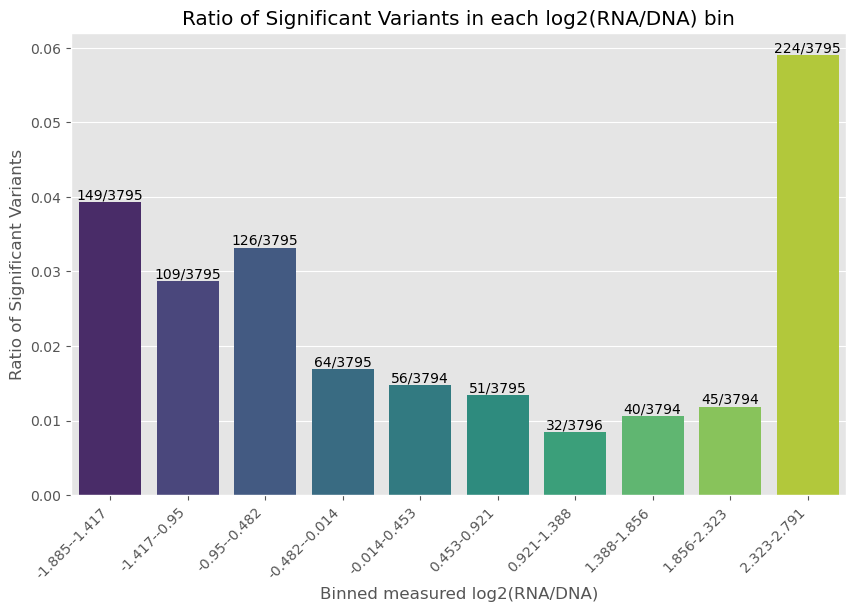

In [407]:
reference_logfc_activity_col = "bcalm_reference_log_ratio_activity"
# Calculate the range of REF_mean_log2
min_value = variant_bcalm_exists_metadata_df_gnomad_info[reference_logfc_activity_col].min()
max_value = variant_bcalm_exists_metadata_df_gnomad_info[reference_logfc_activity_col].max()
# max_value = 2

# Define the number of bins
num_bins = 10

# Prepare bin edges
bin_edges = np.linspace(min_value, max_value, num_bins + 1)
bin_edges
# Prepare bin labels
bin_labels = [f'{round(bin_edges[i],3)}-{round(bin_edges[i+1], 3)}' for i in range(len(bin_edges) - 1)]
bin_labels
# # Create bins for REF_mean_log2 with specified labels
variant_bcalm_exists_metadata_df_gnomad_info['REF_mean_log2_bin'] = pd.qcut(variant_bcalm_exists_metadata_df_gnomad_info[reference_logfc_activity_col], q=num_bins, labels=bin_labels)

# variant_bcalm_exists_metadata_df_gnomad_info['REF_mean_log2_bin'] = pd.cut(variant_bcalm_exists_metadata_df_gnomad_info[reference_logfc_activity_col], bins=bin_edges, labels=bin_labels, right=False)

# Group by the bins and count the number of significant and non-significant variants
bin_group = variant_bcalm_exists_metadata_df_gnomad_info.groupby(['REF_mean_log2_bin', 'is_significant']).size().unstack(fill_value=0)

# Calculate the ratio of significant variants in each bin
bin_group['ratio_significant'] = bin_group['yes'] / (bin_group['yes'] + bin_group['no'])

# Reset index to make 'REF_mean_log2_bin' a regular column
bin_group.reset_index(inplace=True)

# Create the bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=bin_group, x='REF_mean_log2_bin', y='ratio_significant', palette='viridis')

# Add labels and title
plt.xlabel('Binned measured log2(RNA/DNA)')
plt.ylabel('Ratio of Significant Variants')
plt.title('Ratio of Significant Variants in each log2(RNA/DNA) bin')
# Rotate x-axis labels by 45 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


# Annotate the number of observations in each group
for index, row in bin_group.iterrows():
    ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')

# if storing:
#     plt.savefig(os.path.join(plot_directory, f'significant_ratio_per_binned_dnase_{name_addition}{column_name}.png'), dpi=300, bbox_inches='tight')

# plt.savefig(os.path.join(plot_directory, f'significant_ratio_per_binned_measured_log2FC_all_results.png'), dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

In [419]:

def merge_bin_description(row, column_name):
    """Expect row to have REF_mean_log2_bin, pos, neg columns"""
    return f"{row[column_name + '_bin']} (+: {row['pos']}, -: {row['neg']})"


def plot_binned_columns_significants_ratios_pos_neg(merged_bcMPRAlm_snakeflow_info, column_name, x_label, y_label, plot_title, storing=False, name_addition=''):
    # Calculate the range of column_name
    min_value_seq = merged_bcMPRAlm_snakeflow_info[column_name].min()
    max_value_seq = merged_bcMPRAlm_snakeflow_info[column_name].max()

    # Define the number of bins
    num_bins_seq = 10

    # Prepare bin edges
    bin_edges_seq = np.linspace(min_value_seq, max_value_seq, num_bins_seq + 1)

    # Prepare bin labels
    bin_labels_seq = [f'{round(bin_edges_seq[i], 3)}-{round(bin_edges_seq[i+1], 3)}' for i in range(len(bin_edges_seq) - 1)]

    # Create bins for column_name with specified labels
    merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)

    # Group by the bins and count the number of significant and non-significant variants
    bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)

    # Calculate the ratio of significant variants in each bin
    bin_group_seq['ratio_significant'] = bin_group_seq['yes'] / (bin_group_seq['yes'] + bin_group_seq['no'])

    # only significant:
    significant_merged_bcMPRAlm_snakeflow_info = merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info["is_significant"] == "yes"]

    # group for getting the number of pos and neg
    bin_group_effect_direction = significant_merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'effect_direction']).size().unstack(fill_value=0).reset_index()
    # bin_group['ratio_'] = bin_group['yes'] / (bin_group['yes'] + bin_group['no'])
    bin_group_effect_direction['merged_bin_description'] = bin_group_effect_direction.apply(lambda x: merge_bin_description(x, column_name), axis=1)

    # Reset index to make column_name + '_bin' a regular column
    bin_group_seq.reset_index(inplace=True)

    # merge bin_group_effect_direction and bin_group
    bin_group_seq = bin_group_seq.merge(bin_group_effect_direction, on=column_name + '_bin', how='left')

    # Create the bar plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=bin_group_seq, x='merged_bin_description', y='ratio_significant', palette='viridis')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(plot_title)

    # x limit
    plt.ylim(0,0.065)

    # Rotate x-axis labels by 45 degrees
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Annotate the number of observations in each group
    for index, row in bin_group_seq.iterrows():
        ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')

    if storing:
        plt.savefig(os.path.join(plot_directory, f'pos_neg_significant_ratio_per_binned_dnase_{column_name}{name_addition}.png'), dpi=300, bbox_inches='tight')

    # Show the plot
    plt.show()


In [413]:
def get_effect_direction(variant_log2fc):
    return 'pos' if variant_log2fc > 0 else 'neg'

variant_bcalm_exists_metadata_df_gnomad_info['effect_direction'] = variant_bcalm_exists_metadata_df_gnomad_info['bcalm_variant_effect_log_ratio_activity'].apply(get_effect_direction)


/tmp/ipykernel_791278/3521124387.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_791278/3521124387.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_effect_direction = significant_merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'effect_direction']).size().unstack(fill_value=0).reset_index()
/tmp/ipykernel_791278/3521124387.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign

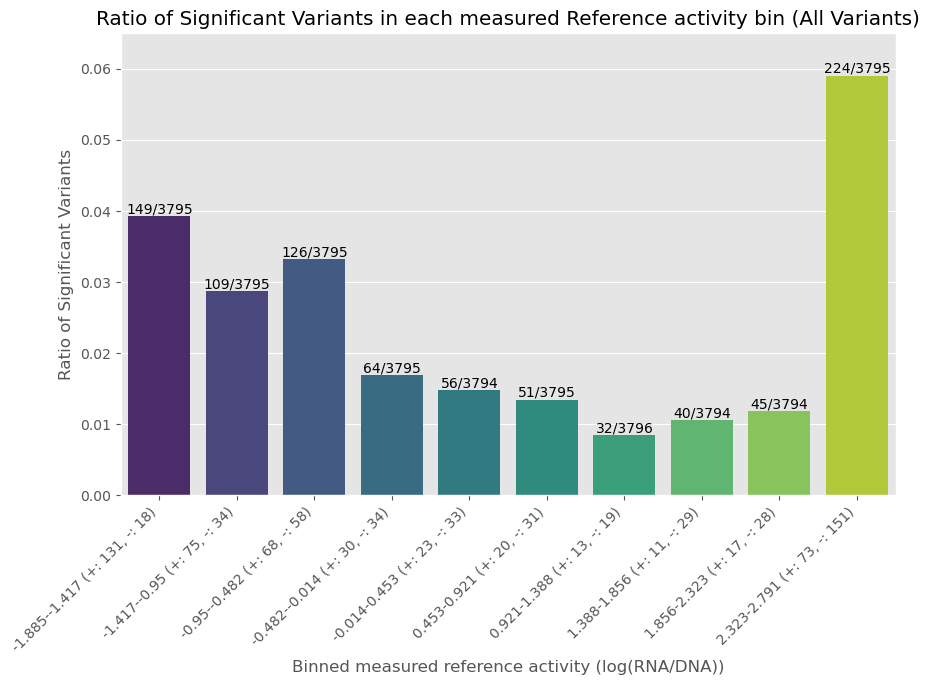

In [420]:
plot_binned_columns_significants_ratios_pos_neg(variant_bcalm_exists_metadata_df_gnomad_info, 'bcalm_reference_log_ratio_activity', 'Binned measured reference activity (log(RNA/DNA))', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each measured Reference activity bin (All Variants)', storing=False, name_addition='_all_results_')


# Did I forget about the random variants? Which are random? Get the enformer data first, right?
- we can do the computations first 

In [ ]:
variant_bcalm_exists_metadata_df_gnomad_info.groupby("variant_rarety_class").

In [ ]:
variant_bcalm_exists_metadata_df_gnomad_info